# **Análisis Predictivo de Ventas por Tipo de Producto**
# Asignatura 7: Modelado Predictivo con Machine Learning

# Conectarse con la API de kaggle

Para usar la API de kaggle, tenemos que cargar el archivo kaggle.json en la ruta /root/.config/kaggle, este archivo se obtiene del API Token desde tu cuenta de Kagle https://www.kaggle.com/settings en la opción Create Legacy API Key.

El archibo kaggle.json se puede subir con el siguiente codigo, después de subirlo se debe de reiniciar la sesión. Este código solo se debe de ejecutar una sola vez.

In [ ]:
# Ejecutar solo una vez
from google.colab import files
import os
import shutil

# Subir archivo kaggle.json
print("Sube tu archivo 'kaggle.json'.")
uploaded = files.upload()

# Asegurarse de que el archivo se subió correctamnete
if 'kaggle.json' in uploaded:
    # Crea el directorio .kaggle si no existe
    kaggle_dir = os.path.expanduser('~/.kaggle')
    os.makedirs(kaggle_dir, exist_ok=True)

    # Mueve el archivo kaggle.json al directorio correcto
    shutil.move('kaggle.json', os.path.join(kaggle_dir, 'kaggle.json'))

    # Establece los permisos correctos para el archivo
    os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)

    print("\nArchivo 'kaggle.json' se subió exitosamente.\n")
    print("¡***IMPORTANTE***: Reiniciar el entorno de ejecución de Colab (Runtime > Restart session) para que puedas usar la API de Kaggle!")
else:
    print("No se subió el archivo 'kaggle.json'. Inténtalo de nuevo.")

Sube tu archivo 'kaggle.json'.


Saving kaggle.json to kaggle.json

Archivo 'kaggle.json' se subió exitosamente.

¡***IMPORTANTE***: Reiniciar el entorno de ejecución de Colab (Runtime > Restart session) para que puedas usar la API de Kaggle!


In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import kaggle
import warnings
import os
import requests

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 100

# Preprocesamiento y métricas
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import Ridge
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats as sp_stats

## Obtener dataset de Kaggle



In [ ]:
# Verificar que kaggle.json este correctamente configurado
kaggle_json_path = os.path.expanduser('~/.kaggle/kaggle.json')

if os.path.exists(kaggle_json_path):
    print(f"El archivo 'kaggle.json' existe en: {kaggle_json_path}")
    permissions = oct(os.stat(kaggle_json_path).st_mode & 0o777)
    if permissions == '0o600':
        print(f"Los permisos son correctos: {permissions}")
        print("Kaggle.json parece estar configurado correctamente.")
    else:
        print(f"Los permisos del archivo 'kaggle.json' no son correctos. Se esperan '0o600', pero son '{permissions}'.")
else:
    print(f"El archivo 'kaggle.json' no se encontró en: {kaggle_json_path}")

# Crear carpeta de descarga si no existe
os.makedirs("data", exist_ok=True)

El archivo 'kaggle.json' existe en: /root/.kaggle/kaggle.json
Los permisos son correctos: 0o600
Kaggle.json parece estar configurado correctamente.


In [ ]:
# Obtenemos los dataset con la API de Kaggle
kaggle.api.dataset_download_files(
    "olistbr/brazilian-ecommerce",
    path="data",
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


In [ ]:
# Cargamos los datasets necesarios
orders      = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
products    = pd.read_csv('data/olist_products_dataset.csv')
categories  = pd.read_csv('data/product_category_name_translation.csv')

In [ ]:
# Filtramos las ordenes que fueron entregadas
orders = orders[orders["order_status"] == "delivered"]
orders = orders[
    ["order_id", "order_purchase_timestamp"]
]

# Obtenemos solo los campos necesarios
order_items = order_items[
    ["order_id", "product_id", "price", "freight_value"]
]

products = products[
    ["product_id", "product_category_name"]
]

In [ ]:
#Realizamos la unión de los valores de las tablas en un sólo dataframe
df = orders.merge(
    order_items,
    on="order_id",
    how="inner"
)

df = df.merge(
    products,
    on="product_id",
    how="left"
)

df = df.merge(
    categories,
    on="product_category_name",
    how="left"
)

In [ ]:
# Convertimos el campo order_purchase_timestamp en valor de tipo datetime
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"]
)

In [ ]:
# Llenamos los nulos con valor default para product_category_name_english
df["product_category_name_english"] = df[
    "product_category_name_english"
].fillna("unknown")

In [ ]:
# Quitamos los registros con precio nulo
df = df.dropna(subset=["price"])

In [ ]:
# Creamos un dataframe final limpio
df_final = df[
    [
        "order_purchase_timestamp",
        "order_id",
        "product_id",
        "product_category_name_english",
        "price",
        "freight_value"
    ]
].copy()

In [ ]:
# Agregamos campo de fecha
df_final["date"] = df_final["order_purchase_timestamp"].dt.date

In [ ]:
# Guardamos dentro del notebook como csv
df_final.to_csv("tabla_analitica_olist.csv", index=False)

In [ ]:
# Ventas diarias
df_ventas_diarias = (
    df_final
    .groupby(['date', 'product_category_name_english'])
    .agg(unidades_vendidas=('product_id', 'count'))
    .reset_index()
    .rename(columns={'date': 'fecha_venta', 'product_category_name_english': 'categoria'})
    .sort_values('fecha_venta')
    .reset_index(drop=True)
)

# Ventas mensuales
df_ventas_mensuales = (
    df_final
    .assign(
        year=pd.to_datetime(df_final['order_purchase_timestamp']).dt.year,
        month=pd.to_datetime(df_final['order_purchase_timestamp']).dt.month
    )
    .groupby(['year', 'month', 'product_category_name_english'])
    .agg(unidades_vendidas=('product_id', 'count'))
    .reset_index()
    .rename(columns={'product_category_name_english': 'categoria'})
)
df_ventas_mensuales['fecha_venta'] = pd.to_datetime(
    df_ventas_mensuales[['year', 'month']].assign(day=1)
)
df_ventas_mensuales = (
    df_ventas_mensuales
    .drop(columns=['year', 'month'])
    .sort_values('fecha_venta')
    .reset_index(drop=True)
)

print(df_ventas_mensuales.head())


       categoria  unidades_vendidas fecha_venta
0  health_beauty                  3  2016-09-01
1  watches_gifts                  4  2016-10-01
2        unknown                  2  2016-10-01
3           toys                 24  2016-10-01
4      telephony                  8  2016-10-01


In [ ]:
df_ventas_mensuales.to_csv('ventas_mensuales_TFM.csv', index=False)
df_ventas_diarias.to_csv('ventas_diarias_TFM.csv', index=False)

# 1. Análisis Exploratorio de Datos (EDA)

In [ ]:
tabla_desc = df_ventas_mensuales.groupby('categoria')['unidades_vendidas'].describe()
tabla_desc

,count,mean,std,min,25%,50%,75%,max
categoria,,,,,,,,
agro_industry_and_commerce,19.0,10.842105,8.889839,1.0,4.00,8.0,18.00,27.0
air_conditioning,21.0,13.761905,6.934730,3.0,8.00,14.0,17.00,29.0
art,18.0,10.944444,10.574510,1.0,3.00,5.0,18.75,34.0
arts_and_craftmanship,6.0,4.000000,4.690416,1.0,1.00,1.0,7.00,11.0
audio,20.0,18.100000,10.140591,2.0,10.75,17.0,26.00,36.0
...,...,...,...,...,...,...,...,...
tablets_printing_image,17.0,4.882353,3.551098,1.0,2.00,5.0,6.00,13.0
telephony,21.0,210.952381,102.287084,8.0,143.00,216.0,271.00,371.0
toys,21.0,191.904762,112.619228,24.0,139.00,182.0,218.00,485.0


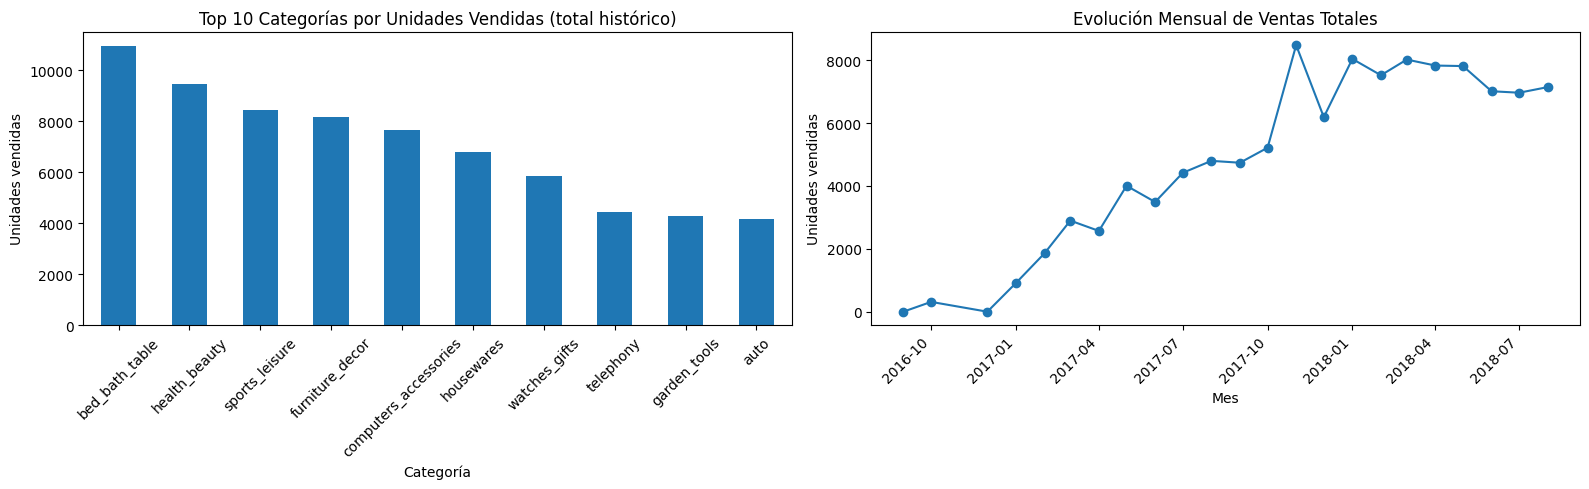

In [ ]:
# Top 10 categorías por volumen total de ventas
top10 = (
    df_ventas_mensuales
    .groupby('categoria')['unidades_vendidas']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top10.plot(kind='bar', ax=axes[0])
axes[0].set_title('Top 10 Categorías por Unidades Vendidas (total histórico)')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Unidades vendidas')
axes[0].tick_params(axis='x', rotation=45)

evolucion = df_ventas_mensuales.groupby('fecha_venta')['unidades_vendidas'].sum()
evolucion.plot(ax=axes[1], marker='o')
axes[1].set_title('Evolución Mensual de Ventas Totales')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Unidades vendidas')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



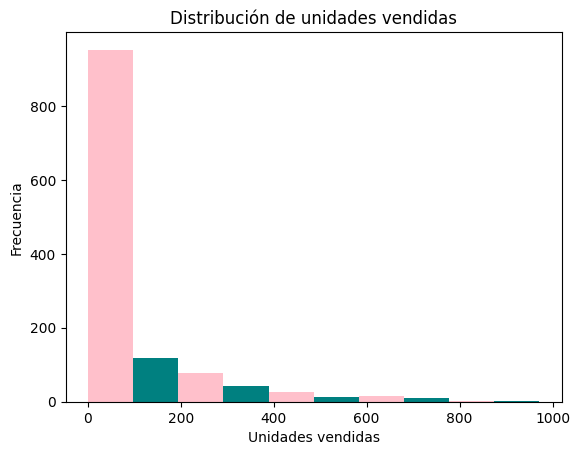

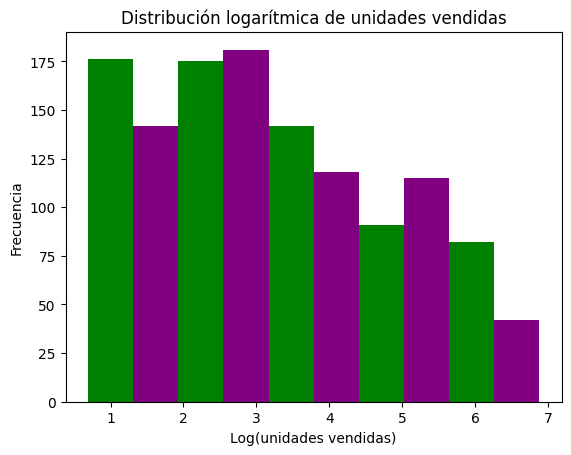

In [ ]:
# Histogramas de distribución

import matplotlib.pyplot as plt
import numpy as np

# Crear variable log (si no existe)
df_ventas_mensuales['cantidad_log'] = np.log1p(df_ventas_mensuales['unidades_vendidas'])

# Histograma original
counts, bins, patches = plt.hist(df_ventas_mensuales['unidades_vendidas'])

colores = ['pink', 'teal'] * len(patches)

for patch, color in zip(patches, colores):
    patch.set_facecolor(color)

plt.title("Distribución de unidades vendidas")
plt.xlabel("Unidades vendidas")
plt.ylabel("Frecuencia")
plt.show()

# Histograma logarítmico
counts, bins, patches = plt.hist(df_ventas_mensuales['cantidad_log'])

colores = ['green', 'purple'] * len(patches)

for patch, color in zip(patches, colores):
    patch.set_facecolor(color)

plt.title("Distribución logarítmica de unidades vendidas")
plt.xlabel("Log(unidades vendidas)")
plt.ylabel("Frecuencia")
plt.show()

Número de categorías: 72
Categorías que representan el 80% de las ventas: 15


<Figure size 1400x600 with 0 Axes>

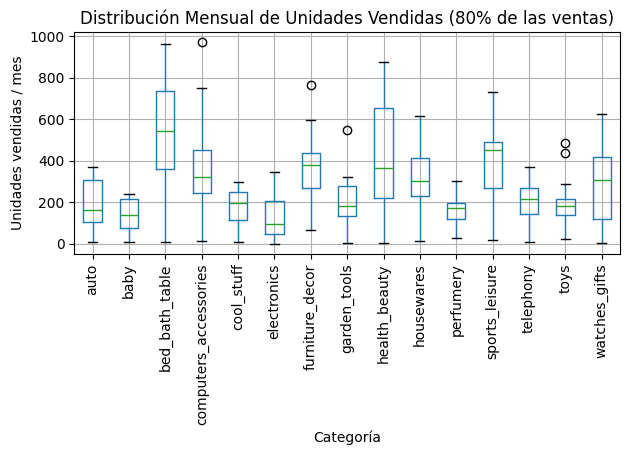


Estadísticas descriptivas mensuales (80% de las ventas):
                       count    mean     std   min    25%    50%    75%    max
categoria                                                                     
auto                    21.0  197.14  117.98   8.0  107.0  161.0  308.0  370.0
baby                    21.0  142.00   75.96  11.0   78.0  139.0  214.0  239.0
bed_bath_table          21.0  521.57  260.80   8.0  361.0  546.0  736.0  961.0
computers_accessories   21.0  364.00  236.82  12.0  247.0  320.0  453.0  971.0
cool_stuff              21.0  177.05   83.83   7.0  115.0  199.0  248.0  297.0
electronics             21.0  129.95  104.75   1.0   48.0   94.0  209.0  348.0
furniture_decor         21.0  388.57  168.94  65.0  271.0  378.0  436.0  767.0
garden_tools            21.0  203.24  117.36   5.0  136.0  184.0  280.0  547.0
health_beauty           22.0  430.23  269.77   3.0  219.5  364.0  654.5  875.0
housewares              21.0  323.57  179.06  12.0  229.0  302.0  412.0  

In [ ]:
# Categorías únicas
num_categorias = df_ventas_mensuales['categoria'].nunique()
print(f'Número de categorías: {num_categorias}')

# Total de ventas por categoría (suma mensual acumulada)
ventas_por_categoria = (
    df_ventas_mensuales
    .groupby('categoria')['unidades_vendidas']
    .sum()
    .sort_values(ascending=False)
)

# Porcentaje acumulado (regla de Pareto)
porcentaje_acumulado = ventas_por_categoria.cumsum() / ventas_por_categoria.sum()
categorias_80 = porcentaje_acumulado[porcentaje_acumulado <= 0.8].index
print(f'Categorías que representan el 80% de las ventas: {len(categorias_80)}')

df_80 = df_ventas_mensuales[df_ventas_mensuales['categoria'].isin(categorias_80)]

# Boxplot mensual
plt.figure(figsize=(14, 6))
df_80.boxplot(column='unidades_vendidas', by='categoria', rot=90)
plt.title('Distribución Mensual de Unidades Vendidas (80% de las ventas)')
plt.suptitle('')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas / mes')
plt.tight_layout()
plt.show()

print('\nEstadísticas descriptivas mensuales (80% de las ventas):')
stats_80 = (
    df_80
    .groupby('categoria')['unidades_vendidas']
    .describe()
    .round(2)
)
print(stats_80)

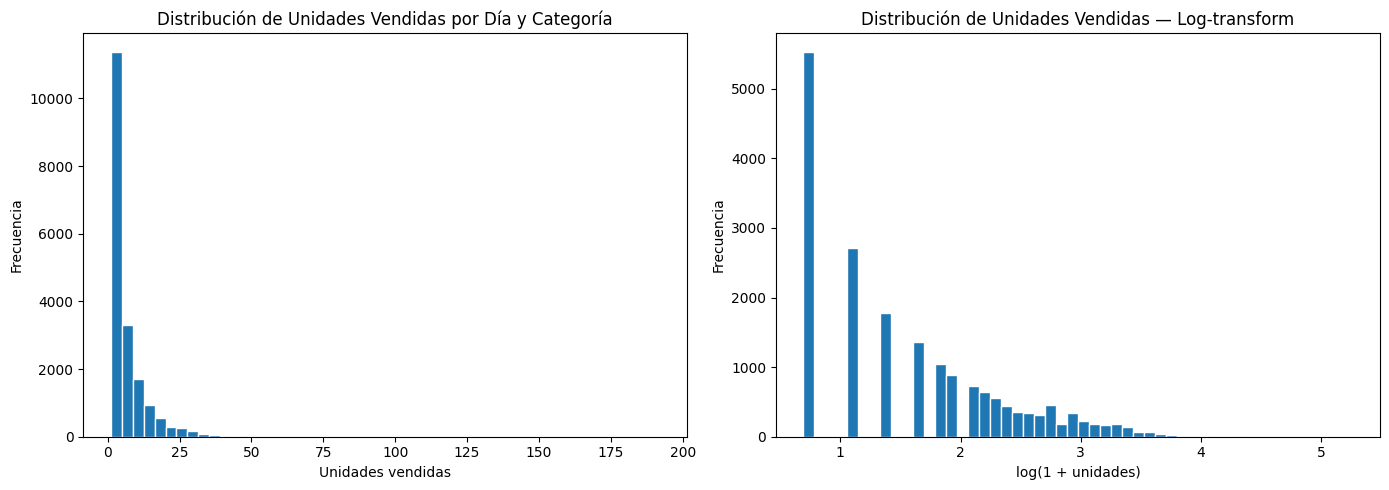

In [ ]:
# Distribución de unidades vendidas por día y categoría
# (se usa granularidad diaria para visualizar la cola de la distribución)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_ventas_diarias['unidades_vendidas'].plot(
    kind='hist', bins=50, ax=axes[0], edgecolor='white')
axes[0].set_title('Distribución de Unidades Vendidas por Día y Categoría')
axes[0].set_xlabel('Unidades vendidas')
axes[0].set_ylabel('Frecuencia')

np.log1p(df_ventas_diarias['unidades_vendidas']).plot(
    kind='hist', bins=50, ax=axes[1], edgecolor='white')
axes[1].set_title('Distribución de Unidades Vendidas — Log-transform')
axes[1].set_xlabel('log(1 + unidades)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

El análisis exploratorio muestra que las ventas se concentran en un conjunto reducido de categorías, evidenciando una distribución desigual típica en entornos de comercio electrónico. Asimismo, la evolución temporal refleja variaciones a lo largo del tiempo, lo que justifica el uso de modelos de series temporales para capturar patrones y tendencias.

La distribución de las ventas presenta asimetría positiva, con presencia de valores extremos, lo cual se atenúa mediante la transformación logarítmica, facilitando su posterior modelado.

# 2. Preprocesamiento de Datos

Preparamos las variables para el entrenamiento de los modelos supervisados aplicando:

- **Log-transform**: `log1p` sobre `cantidad` para reducir el sesgo positivo observado en el EDA
- **Escalado**: `StandardScaler` sobre la variable temporal continua `tiempo`
- **Codificación de categóricas**: OneHotEncoding sobre `tipo_producto`.


Estas transformaciones mejoran la estabilidad numérica y la calidad de los modelos lineales.

In [ ]:
df_model = df_ventas_mensuales.copy()

df_model = df_model.rename(columns={
    'fecha_venta':     'fecha_hora',
    'categoria':       'tipo_producto',
    'unidades_vendidas': 'cantidad'
})

# fecha_hora ya es datetime (primer día de cada mes)
df_model['fecha_hora'] = pd.to_datetime(df_model['fecha_hora'])
df_model['año']  = df_model['fecha_hora'].dt.year
df_model['mes']  = df_model['fecha_hora'].dt.month

# Variable temporal continua: cada unidad = 1 mes
df_model['tiempo'] = df_model['año'] * 12 + df_model['mes']

df_model.head()

,tipo_producto,cantidad,fecha_hora,cantidad_log,año,mes,tiempo
0,health_beauty,3,2016-09-01,1.386294,2016,9,24201
1,watches_gifts,4,2016-10-01,1.609438,2016,10,24202
2,unknown,2,2016-10-01,1.098612,2016,10,24202
3,toys,24,2016-10-01,3.218876,2016,10,24202
4,telephony,8,2016-10-01,2.197225,2016,10,24202


In [ ]:
# Agrupar por tiempo y tipo_producto

df_agg = (
    df_model
    .groupby(["tiempo", "tipo_producto"], as_index=False)
    .agg({"cantidad": "sum"})
)

df_agg.head()

,tiempo,tipo_producto,cantidad
0,24201,health_beauty,3
1,24202,air_conditioning,8
2,24202,audio,2
3,24202,auto,8
4,24202,baby,11


##2.1 Log-Transform y Escalado


La distribución de cantidad presenta fuerte asimetría a la derecha (cola larga). Aplicamos **log1p** para acercarla a una distribución más estable, lo cual beneficia a los modelos lineales. Adicionalmente, escalamos **tiempo** con **StandardScaler** para evitar que su magnitud domine sobre las variables generadas posteriormente mediante codificación categórica.




In [ ]:
# Log-transform sobre cantidad
df_agg['cantidad_log'] = np.log1p(df_agg['cantidad'])

# Escalado de la variable temporal
scaler_tiempo = StandardScaler()
df_agg['tiempo_scaled'] = scaler_tiempo.fit_transform(df_agg[['tiempo']])

df_agg[['tiempo', 'tiempo_scaled', 'tipo_producto', 'cantidad', 'cantidad_log']].head(10)

,tiempo,tiempo_scaled,tipo_producto,cantidad,cantidad_log
0,24201,-2.312308,health_beauty,3,1.386294
1,24202,-2.142568,air_conditioning,8,2.197225
2,24202,-2.142568,audio,2,1.098612
3,24202,-2.142568,auto,8,2.197225
4,24202,-2.142568,baby,11,2.484907
5,24202,-2.142568,bed_bath_table,8,2.197225
6,24202,-2.142568,computers_accessories,12,2.564949
7,24202,-2.142568,consoles_games,7,2.079442
8,24202,-2.142568,cool_stuff,7,2.079442
9,24202,-2.142568,diapers_and_hygiene,1,0.693147


##2.2 Codificación de variables categóricas (OneHotEncoding)

In [ ]:
# Encoder de categorías (útil para la regresión lineal y Random Forest, ARIMA no lo necesita)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(df_agg[['tipo_producto']])

# Vista de las categorías codificadas
print(f'Categorías únicas: {len(encoder.categories_[0])}')
print('Primeras 5 categorías:', list(encoder.categories_[0][:5]))

Categorías únicas: 72
Primeras 5 categorías: ['agro_industry_and_commerce', 'air_conditioning', 'art', 'arts_and_craftmanship', 'audio']


En esta fase se prepararon las variables para el entrenamiento de los modelos supervisados. Para ello, se construyó una variable temporal continua (tiempo) a partir del año y el mes de la fecha de venta, permitiendo representar la evolución cronológica de las ventas.

Asimismo, se aplicó una transformación logarítmica sobre la variable **cantidad** con el objetivo de reducir la asimetría positiva observada en el análisis exploratorio. Finalmente, la variable temporal fue escalada mediante **StandardScaler**, mejorando la estabilidad numérica y favoreciendo el desempeño de modelos sensibles a la escala, como la regresión lineal.

# 3. Modelo de Regresión Lineal

**Justificación del algoritmo:**
La Regresión Lineal es un modelo base interpretable que permite cuantificar la relación entre el tiempo (variable continua) y la cantidad vendida por categoría de producto. Al incorporar el tipo de producto mediante OneHotEncoding, el modelo aprende una tendencia lineal independiente por categoría.

Es un punto de partida sólido y su interpretabilidad facilita la validación de resultados con el negocio.

In [ ]:
# Variable independiente: tiempo escalado + categoría codificada
X = np.hstack([
    df_agg[['tiempo_scaled']].values,
    encoder.transform(df_agg[['tipo_producto']])
])

# Variable objetivo: cantidad en escala log
y = df_agg['cantidad_log'].values

print('Shape X:', X.shape)
print('Shape y:', y.shape)

Shape X: (1264, 73)
Shape y: (1264,)


## 3.1 División Train / Test (Temporal)

Dividimos el dataset respetando el orden temporal: el **80%** más antiguo para entrenamiento y el **20%** más reciente para test. Esto evita el data leakage que ocurriría con una división aleatoria en datos de series temporales.

In [ ]:
# División temporal: 80% train, 20% test
tiempos_unicos = sorted(df_agg['tiempo'].unique())
split_idx = int(len(tiempos_unicos) * 0.8)
tiempo_corte = tiempos_unicos[split_idx]

mask_train = df_agg['tiempo'] <= tiempo_corte
mask_test  = df_agg['tiempo']  > tiempo_corte

X_train, X_test = X[mask_train], X[mask_test]
y_train, y_test = y[mask_train], y[mask_test]

print(f'Tiempo de corte: {tiempo_corte}')
print(f'Registros en train: {X_train.shape[0]}')
print(f'Registros en test:  {X_test.shape[0]}')

Tiempo de corte: 24220
Registros en train: 1006
Registros en test:  258


## 3.2 Entrenamiento

In [ ]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

## 3.3 Evaluación y Métricas

Evaluamos el modelo sobre el conjunto de test con tres métricas:
- **MAE** (Mean Absolute Error): error medio absoluto
- **RMSE** (Root Mean Squared Error): penaliza errores grandes
- **R²**: proporción de varianza explicada (1.0 = perfecto, 0 = no mejor que la media)

In [ ]:
# Predicciones sobre test
y_pred_lr = modelo.predict(X_test)

# Métricas en escala log
mae_lr   = mean_absolute_error(y_test, y_pred_lr)
rmse_lr  = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr    = r2_score(y_test, y_pred_lr)

print('=== Métricas Regresión Lineal (escala log) ===')
print(f'MAE  : {mae_lr:.4f}')
print(f'RMSE : {rmse_lr:.4f}')
print(f'R2   : {r2_lr:.4f}')

# Métricas en escala original (invertir log-transform)
y_pred_orig = np.expm1(y_pred_lr)
y_test_orig = np.expm1(y_test)
mae_orig  = mean_absolute_error(y_test_orig, y_pred_orig)
rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
print('\n=== Métricas Regresión Lineal (escala original) ===')
print(f'MAE  : {mae_orig:.2f} unidades')
print(f'RMSE : {rmse_orig:.2f} unidades')


=== Métricas Regresión Lineal (escala log) ===
MAE  : 0.7584
RMSE : 0.9227
R2   : 0.6612

=== Métricas Regresión Lineal (escala original) ===
MAE  : 89.44 unidades
RMSE : 173.83 unidades


## 3.4 Predicción Futura (próximos 3 meses)

In [ ]:
from sklearn.linear_model import LinearRegression

# Lista para almacenar las predicciones de cada producto
all_future_predictions = []
productos = df_agg['tipo_producto'].unique()
forecast_steps = 6

# Iterar sobre cada producto para entrenar un modelo y predecir individualmente
for producto in productos:
    df_p = df_agg[df_agg['tipo_producto'] == producto].copy()

    if len(df_p) < 2: # Se necesitan al menos 2 puntos para una regresión lineal simple
        continue

    X = df_p[['tiempo_scaled']].values
    y = df_p['cantidad_log'].values

    # Entrenar un nuevo modelo de Regresión Lineal para este producto
    modelo_prod = LinearRegression()
    modelo_prod.fit(X, y)

    ultimo_tiempo_prod = df_p['tiempo'].max()

    futuros_tiempos_raw = np.array([ultimo_tiempo_prod + i for i in range(1, forecast_steps + 1)])

    futuros_tiempos_scaled = scaler_tiempo.transform(futuros_tiempos_raw.reshape(-1, 1))

    predicciones_log = modelo_prod.predict(futuros_tiempos_scaled)
    predicciones_orig = np.expm1(predicciones_log).clip(0)


    df_pred_prod = pd.DataFrame({
        'tiempo': futuros_tiempos_raw,
        'tiempo_scaled': futuros_tiempos_scaled.flatten(),
        'tipo_producto': producto,
        'cantidad_predicha': predicciones_orig
    })
    all_future_predictions.append(df_pred_prod)


df_futuro = pd.concat(all_future_predictions, ignore_index=True)

df_futuro.head(10)

,tiempo,tiempo_scaled,tipo_producto,cantidad_predicha
0,24225,1.761458,health_beauty,1803.025643
1,24226,1.931198,health_beauty,2107.447025
2,24227,2.100938,health_beauty,2463.238175
3,24228,2.270679,health_beauty,2879.067515
4,24229,2.440419,health_beauty,3365.066225
5,24230,2.610159,health_beauty,3933.075076
6,24225,1.761458,air_conditioning,19.638955
7,24226,1.931198,air_conditioning,20.510401
8,24227,2.100938,air_conditioning,21.418642
9,24228,2.270679,air_conditioning,22.365232


## 3.5 Visualización (Top 10 Categorías por Volumen)

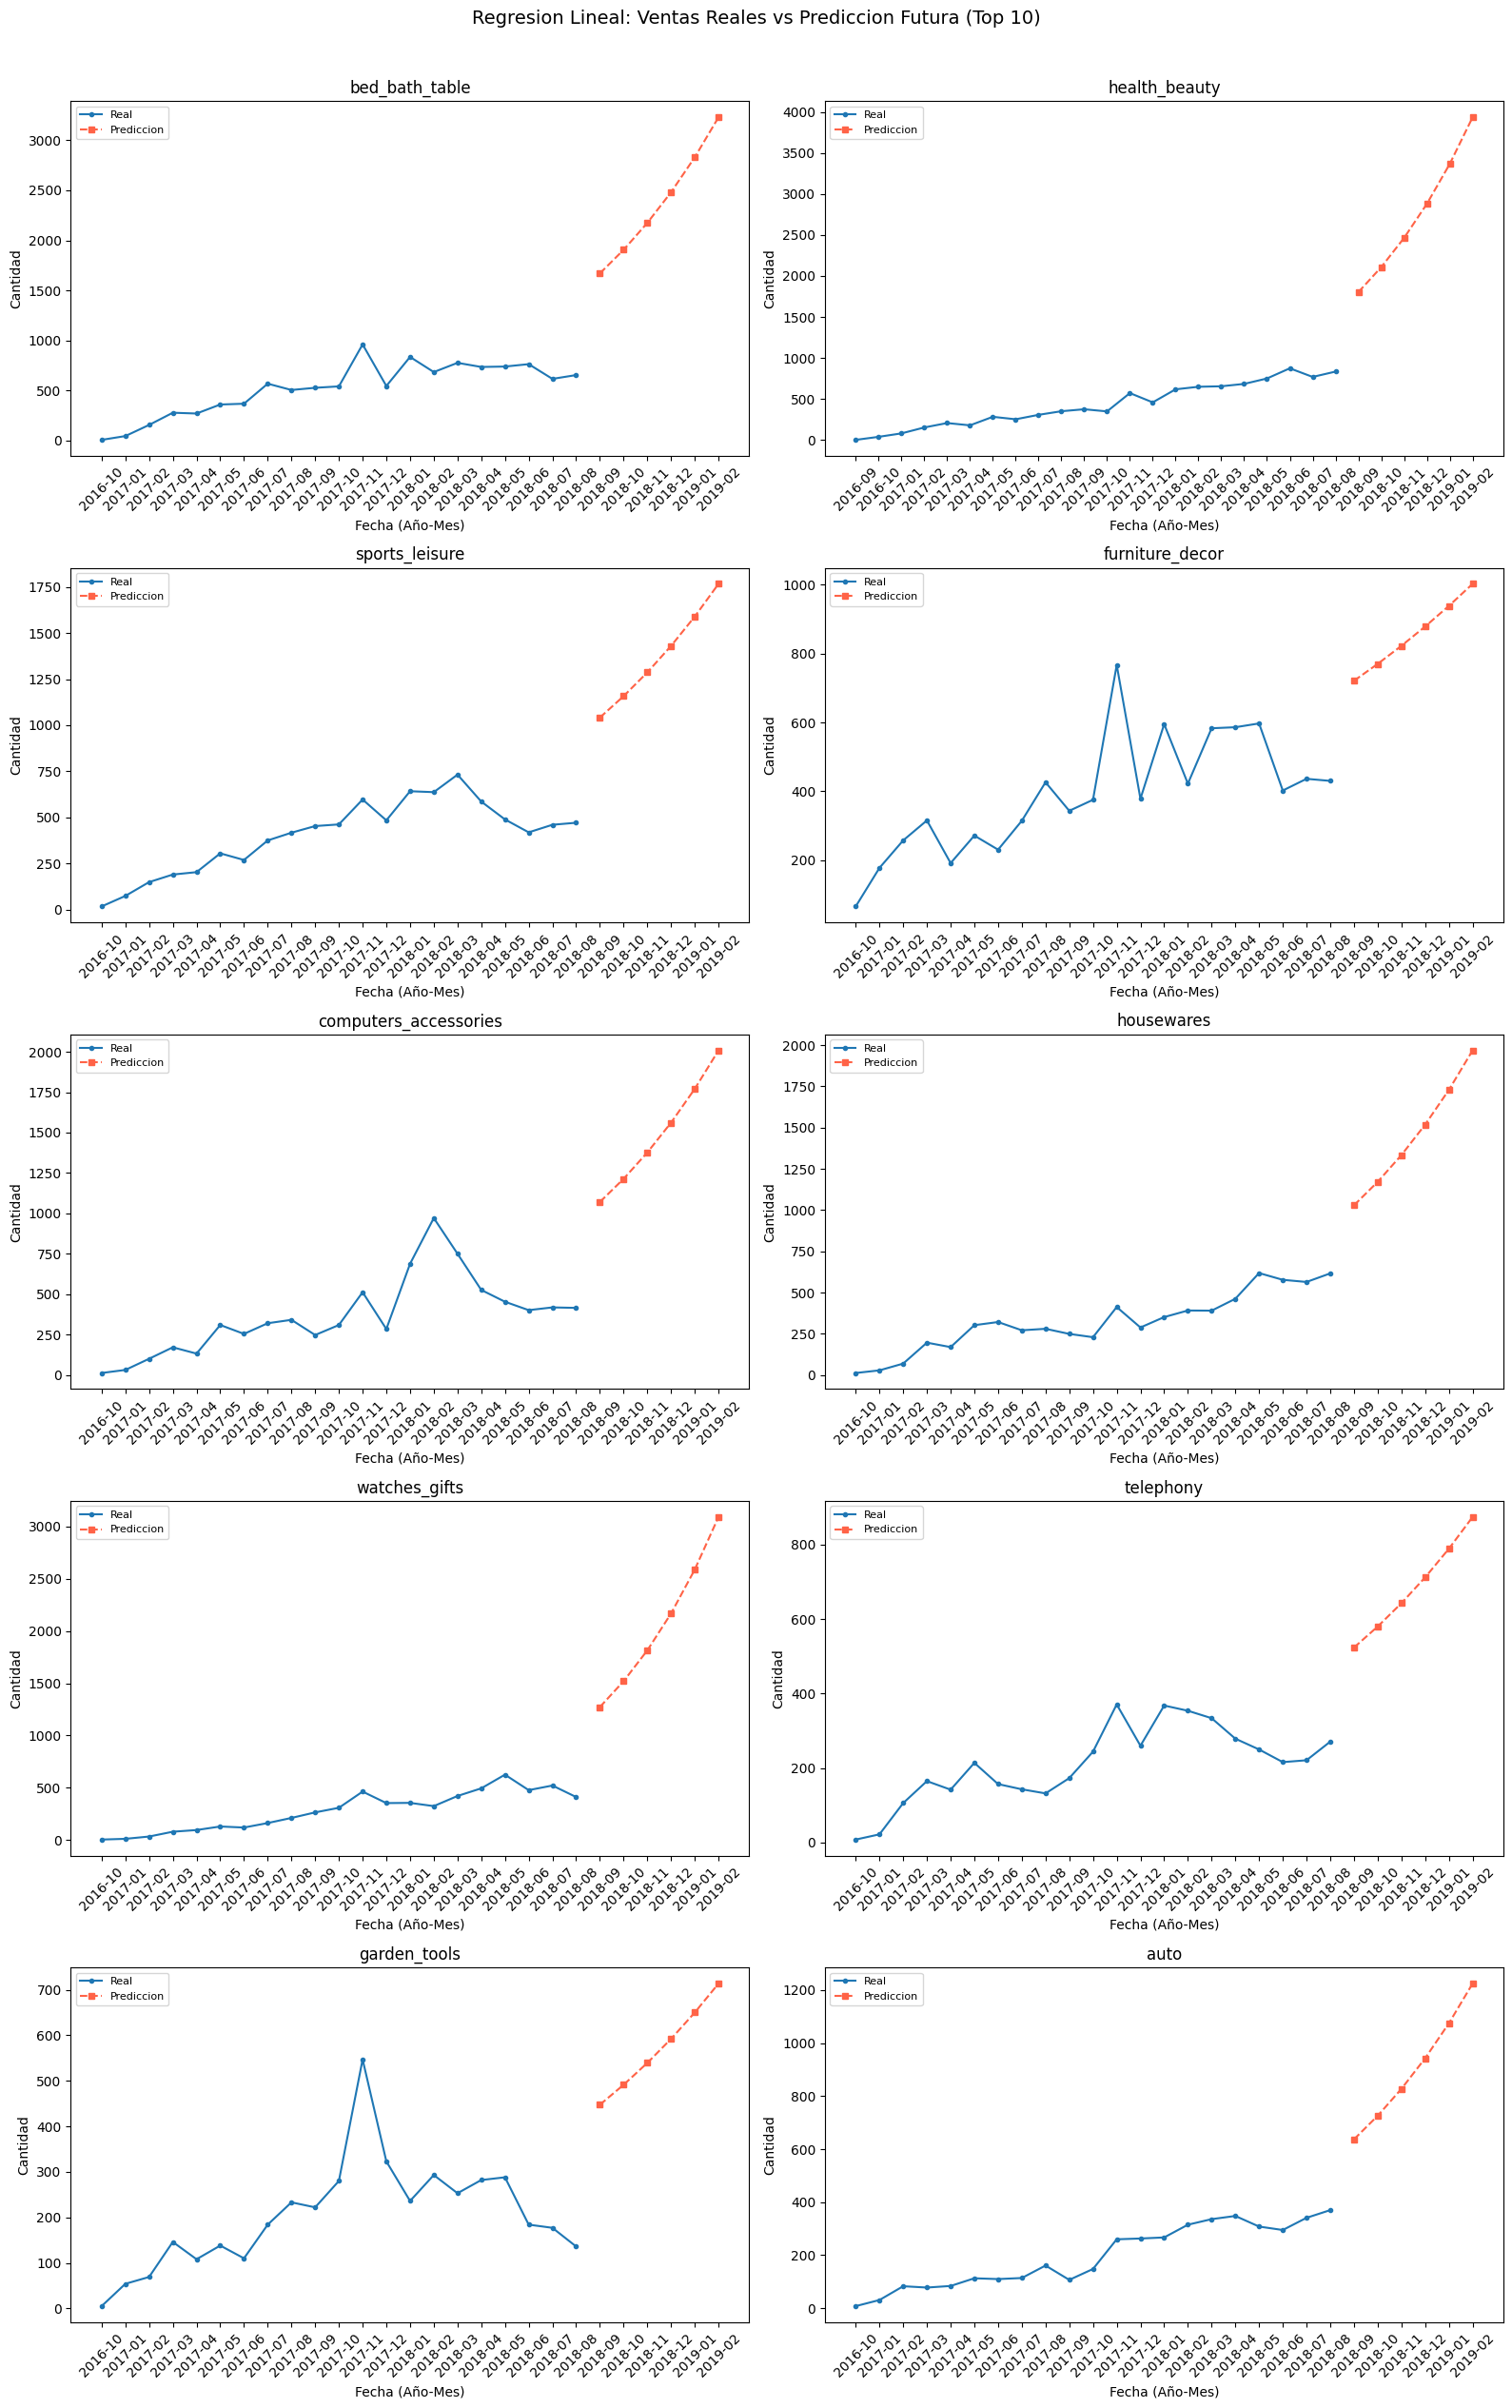

In [233]:
def tiempo_a_fecha(t):
    """Convierte tiempo=año*12+mes a string 'YYYY-MM'."""
    anio = t // 12
    mes  = t % 12
    if mes == 0:
        mes = 12
        anio -= 1
    return pd.Timestamp(year=anio, month=mes, day=1)

top10_cats = (
    df_agg.groupby('tipo_producto')['cantidad'].sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

fig, axes = plt.subplots(5, 2, figsize=(16, 25))
axes = axes.flatten()

for idx, producto in enumerate(top10_cats):
    subset_real = df_agg[df_agg['tipo_producto'] == producto].copy()
    subset_pred = df_futuro[df_futuro['tipo_producto'] == producto].copy()

    # Convertir 'tiempo' a formato de fecha para el eje X
    subset_real['fecha_mes'] = subset_real['tiempo'].apply(tiempo_a_fecha).dt.strftime('%Y-%m')
    subset_pred['fecha_mes'] = subset_pred['tiempo'].apply(tiempo_a_fecha).dt.strftime('%Y-%m')

    # Asegurar el orden cronológico para el gráfico
    subset_real = subset_real.sort_values(by='fecha_mes')
    subset_pred = subset_pred.sort_values(by='fecha_mes')

    ax = axes[idx]
    ax.plot(subset_real['fecha_mes'], np.expm1(subset_real['cantidad_log']), # Usar fecha_mes
            label='Real', marker='o', markersize=3)
    ax.plot(subset_pred['fecha_mes'], subset_pred['cantidad_predicha'], # Usar fecha_mes
            label='Prediccion', linestyle='--', marker='s', markersize=4, color='tomato')
    ax.set_title(producto)
    ax.set_xlabel('Fecha (Año-Mes)') # Cambiar etiqueta del eje X
    ax.set_ylabel('Cantidad')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45) # Rotar y alinear etiquetas

plt.suptitle('Regresion Lineal: Ventas Reales vs Prediccion Futura (Top 10)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3.6 Interpretación

La regresión lineal captura tendencias generales de crecimiento o descenso por categoría. Las categorías con mayor R² presentan una tendencia temporal clara y estable, mientras que aquellas con R² bajo exhiben mayor volatilidad o comportamiento no lineal.

**Limitación principal:** El modelo asume una relación lineal con el tiempo y no captura estacionalidad ni patrones complejos.

Los resultados gráficos muestran que la regresión lineal captura adecuadamente la tendencia general de crecimiento en las distintas categorías de producto. Sin embargo, se observa que el modelo tiende a sobreestimar las ventas futuras, especialmente en categorías con alta variabilidad.

Esto se debe a que la regresión lineal asume una relación estrictamente lineal con el tiempo, lo que impide capturar fluctuaciones, estacionalidad o comportamientos no lineales presentes en los datos reales.

En consecuencia, aunque el modelo resulta útil como línea base por su interpretabilidad, presenta limitaciones claras para modelar dinámicas complejas, lo cual justifica el uso de modelos más avanzados en etapas posteriores del proyecto.

# 4. Modelo ARIMA (AutoRegressive Integrated Moving Average)

**Justificación del algoritmo:**
ARIMA es un modelo estadístico diseñado para series temporales univariadas. A diferencia de la regresión lineal, modela explícitamente:

- **AR(p)**: autocorrelación — las ventas dependen de sus valores pasados
- **I(d)**: diferenciación para hacer la serie estacionaria
- **MA(q)**: componente de media móvil del error de predicción

Se aplica individualmente por categoría de producto, lo que permite capturar patrones específicos de cada tipo. La configuración **(p=1, d=1, q=1)** es una elección estándar y robusta para series de demanda comercial, especialmente como aproximación inicial en un contexto de MVP.

In [ ]:

# Se parte de df_model que ya tiene granularidad mensual
df_arima = df_model[['fecha_hora', 'tipo_producto', 'cantidad']].copy()
df_arima = df_arima.sort_values('fecha_hora').reset_index(drop=True)

In [ ]:
df_arima.head()

,fecha_hora,tipo_producto,cantidad
0,2016-09-01,health_beauty,3
1,2016-10-01,fashion_male_clothing,1
2,2016-10-01,consoles_games,7
3,2016-10-01,fashion_bags_accessories,8
4,2016-10-01,fashio_female_clothing,1


In [ ]:
# Obtener categorías de los productos
categorias = df_arima['tipo_producto'].unique()

In [ ]:
df_arima = df_arima[['fecha_hora','tipo_producto','cantidad']]

In [209]:
# Instalar pmdarima para selección automática de orden ARIMA
!pip install pmdarima -q
from pmdarima import auto_arima

In [210]:
resultados = {}

CONFIG = {
    'forecast_steps': 3,    # pronosticar 3 meses hacia adelante
    'min_datos': 12,        # mínimo 12 meses para modelar
    'test_size':  4,        # últimos 4 meses como test (~20% de ~24 meses)
    'freq': 'MS'            # frecuencia mensual (Month Start)
}

categorias = df_arima['tipo_producto'].unique()

for categoria in categorias:

    df_prod = df_arima[df_arima['tipo_producto'] == categoria]
    serie = df_prod.groupby('fecha_hora')['cantidad'].sum().sort_index()
    serie = serie.asfreq(CONFIG['freq']).fillna(0)

    if len(serie) < CONFIG['min_datos']:
        continue
    if len(serie) <= CONFIG['test_size']:
        continue

    train = serie.iloc[:-CONFIG['test_size']]
    test  = serie.iloc[-CONFIG['test_size']:]

    try:
        modelo_auto = auto_arima(
            train,
            start_p=0, max_p=3,
            start_q=0, max_q=3,
            d=None,
            seasonal=False,
            information_criterion='aic',
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore'
        )
        order_seleccionado = modelo_auto.order

        from statsmodels.tsa.arima.model import ARIMA as ARIMA_sm
        modelo_sm = ARIMA_sm(train, order=order_seleccionado).fit()

        pred            = modelo_sm.forecast(steps=len(test))
        mae             = np.mean(np.abs(test.values - pred.values))
        rmse            = np.sqrt(np.mean((test.values - pred.values)**2))
        forecast_result = modelo_sm.get_forecast(steps=CONFIG['forecast_steps'])
        forecast_mean   = forecast_result.predicted_mean
        forecast_ci     = forecast_result.conf_int(alpha=0.20)

        resultados[categoria] = {
            'serie':       serie,
            'train':       train,
            'test':        test,
            'pred':        pred,
            'forecast':    forecast_mean,
            'forecast_ci': forecast_ci,
            'order':       order_seleccionado,
            'MAE':         mae,
            'RMSE':        rmse
        }
        print(f'{categoria:35s}  order={order_seleccionado}  MAE={mae:.1f}  RMSE={rmse:.1f}')

    except Exception as e:
        print(f'Error en {categoria}: {e}')


health_beauty                        order=(1, 1, 0)  MAE=130.2  RMSE=139.1
fashion_male_clothing                order=(1, 0, 0)  MAE=1.9  RMSE=2.4
consoles_games                       order=(1, 0, 0)  MAE=10.3  RMSE=11.8
fashion_bags_accessories             order=(1, 1, 0)  MAE=21.8  RMSE=25.0
fashio_female_clothing               order=(0, 0, 0)  MAE=1.9  RMSE=2.0
diapers_and_hygiene                  order=(1, 0, 0)  MAE=1.1  RMSE=1.8
cool_stuff                           order=(1, 1, 0)  MAE=94.3  RMSE=97.3
auto                                 order=(0, 1, 1)  MAE=33.2  RMSE=38.4
computers_accessories                order=(0, 1, 0)  MAE=104.2  RMSE=106.0
bed_bath_table                       order=(1, 1, 0)  MAE=67.7  RMSE=84.6
baby                                 order=(2, 1, 0)  MAE=33.6  RMSE=36.8
audio                                order=(0, 1, 0)  MAE=8.7  RMSE=9.0
air_conditioning                     order=(1, 1, 0)  MAE=6.7  RMSE=7.2
fixed_telephony                      order=(

## 4.1 Visualización por Categoría (Top 10 por Volumen)

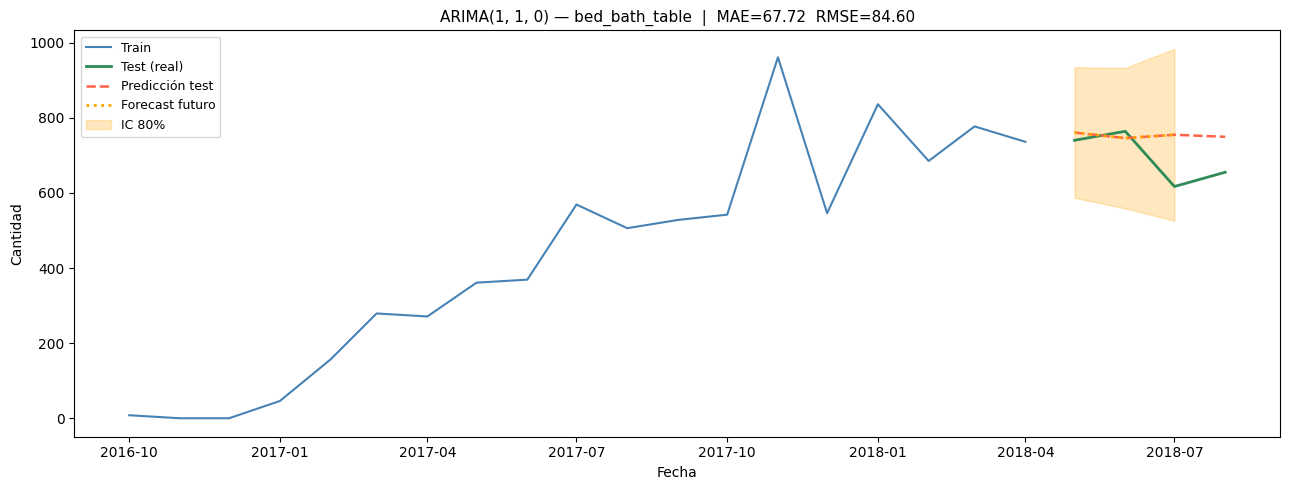

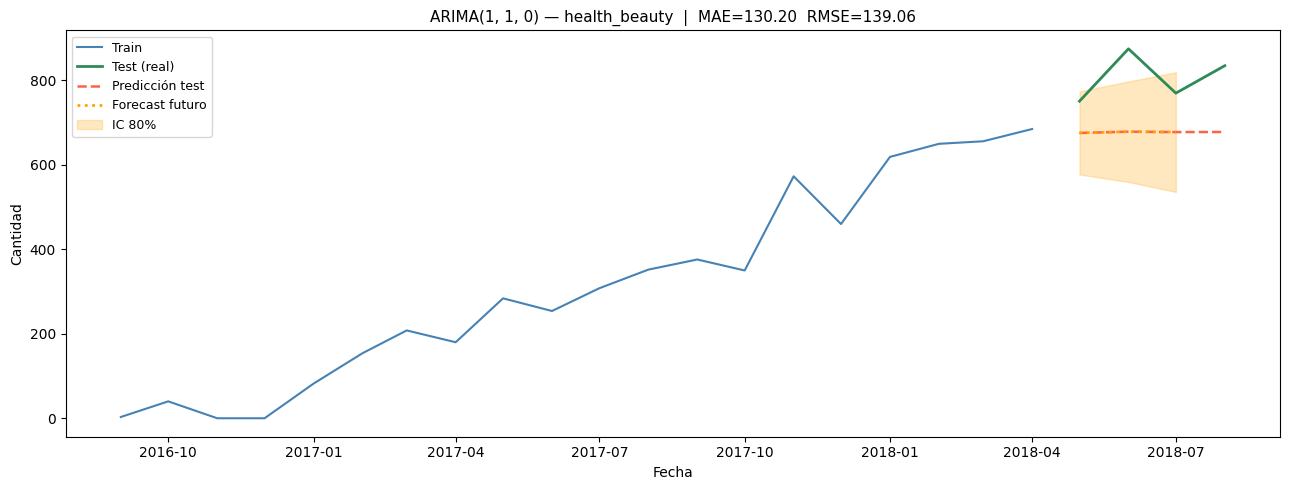

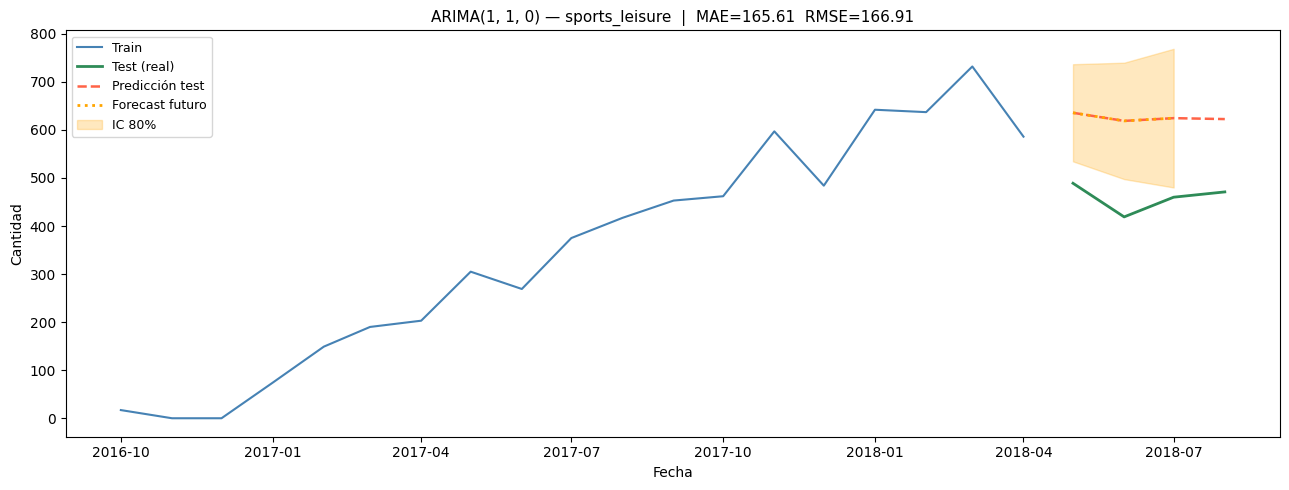

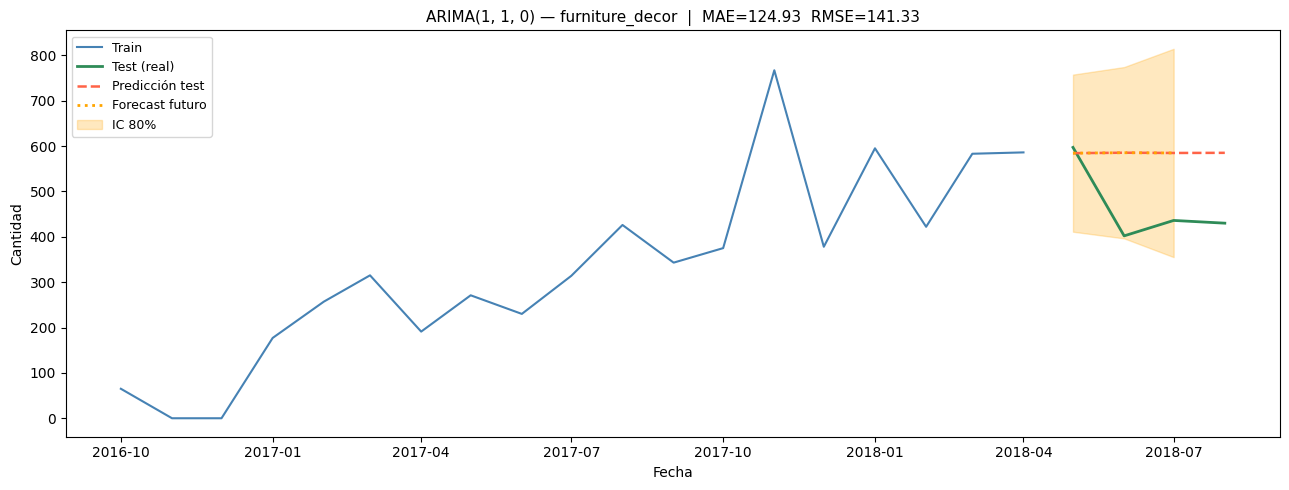

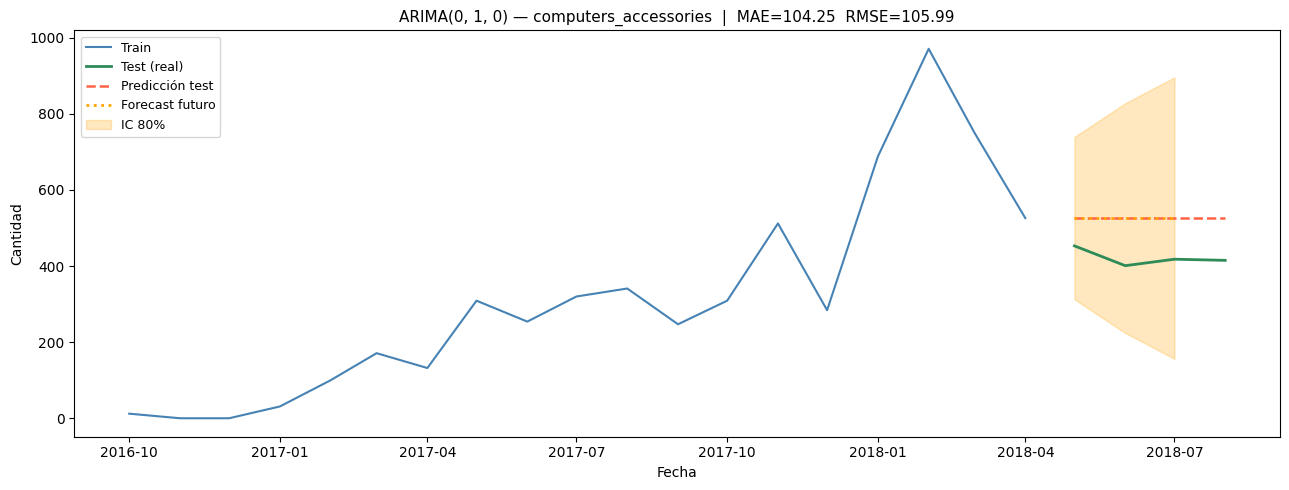

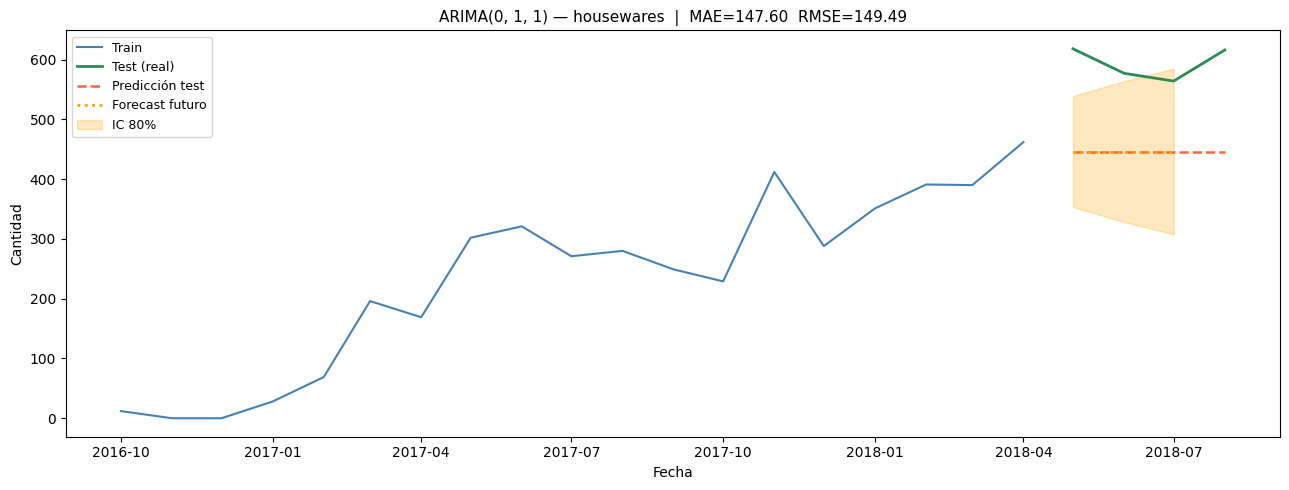

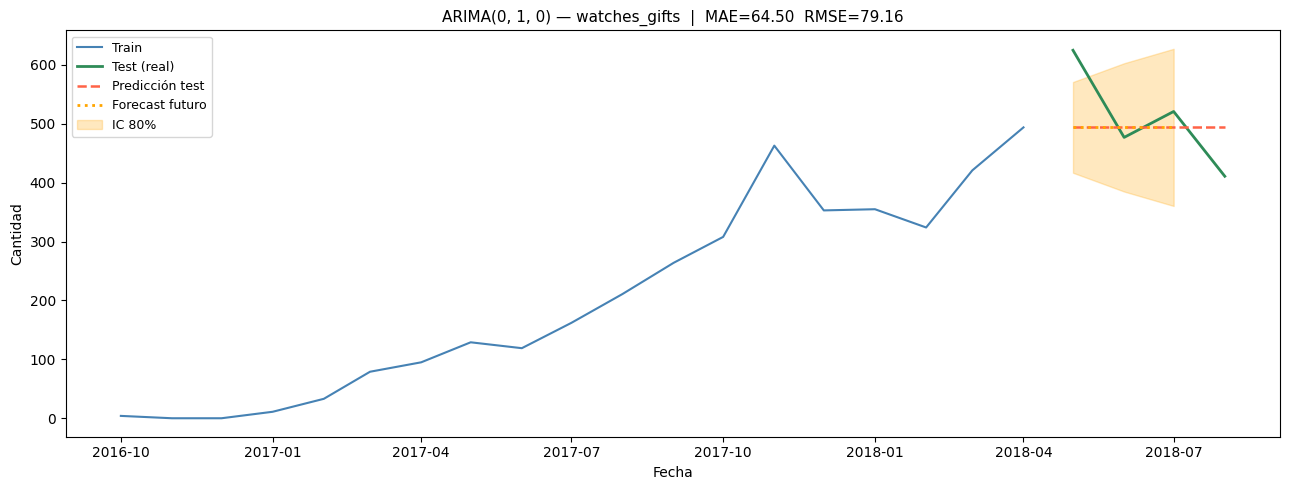

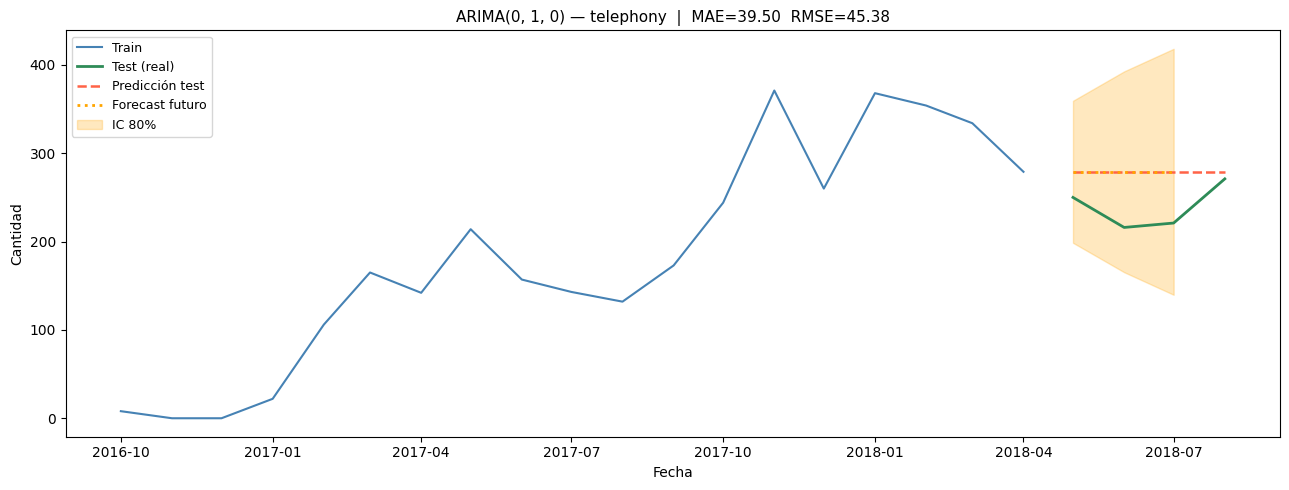

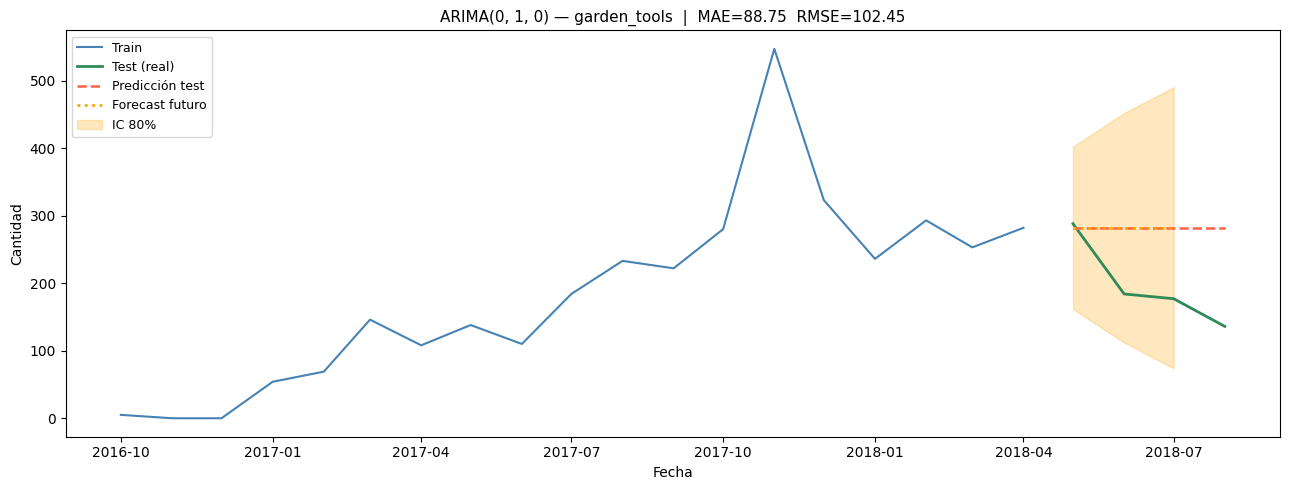

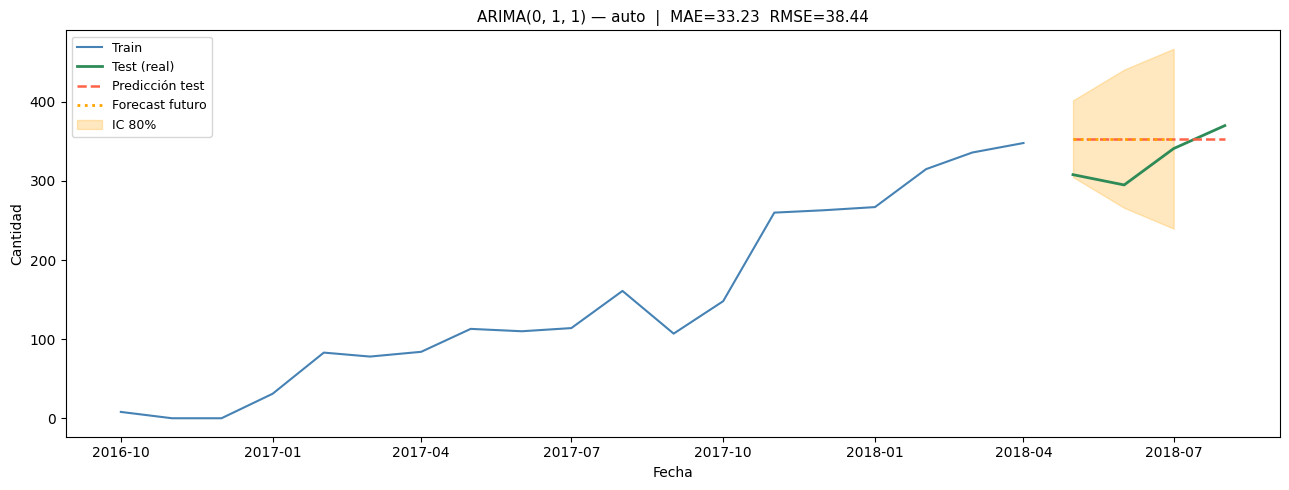

In [ ]:
# Ordenar resultados por volumen total y mostrar top 10
resultados_sorted = sorted(
    resultados.items(),
    key=lambda x: x[1]['serie'].sum(),
    reverse=True
)[:10]

for categoria, res in resultados_sorted:

    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(res['train'], label='Train', color='steelblue', lw=1.5)
    ax.plot(res['test'],  label='Test (real)', color='seagreen', lw=2)
    ax.plot(res['pred'],  linestyle='--', label=f'Predicción test', color='tomato', lw=1.8)
    ax.plot(res['forecast'], linestyle=':', label='Forecast futuro', color='orange', lw=2)

    # Intervalo de confianza 80% para el forecast
    ci = res['forecast_ci']
    ax.fill_between(
        ci.index,
        ci.iloc[:, 0].clip(0),
        ci.iloc[:, 1],
        alpha=0.25, color='orange', label='IC 80%'
    )

    ax.set_title(
        f'ARIMA{res["order"]} — {categoria}  |  MAE={res["MAE"]:.2f}  RMSE={res["RMSE"]:.2f}',
        fontsize=11
    )
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Cantidad')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


## 4.2 Tabla Resumen de Métricas ARIMA

In [212]:
resumen_arima = pd.DataFrame([
    {
        'Categoria': cat,
        'N_obs': len(res['serie']),
        'MAE': round(res['MAE'], 3),
        'RMSE': round(res['RMSE'], 3)
    }
    for cat, res in resultados.items()
]).sort_values('MAE').reset_index(drop=True)

print(f'Categorias modeladas con ARIMA: {len(resumen_arima)}')
print(f'MAE promedio : {resumen_arima["MAE"].mean():.3f}')
print(f'RMSE promedio: {resumen_arima["RMSE"].mean():.3f}')

resumen_arima.head(20)

Categorias modeladas con ARIMA: 69
MAE promedio : 26.140
RMSE promedio: 28.961


,Categoria,N_obs,MAE,RMSE
0,la_cuisine,13,0.556,0.716
1,fashion_childrens_clothes,14,0.750,0.816
2,home_comfort_2,19,1.000,1.122
3,diapers_and_hygiene,23,1.119,1.827
4,fashion_sport,18,1.750,1.803
5,fashio_female_clothing,23,1.855,1.955
6,fashion_male_clothing,23,1.920,2.421
7,computers,20,2.319,2.401
8,christmas_supplies,17,2.433,2.832
9,dvds_blu_ray,20,2.750,2.907


##4.3 Interpretación

Los modelos **ARIMA (1,1,1)** capturan la dinámica de corto plazo de cada categoría, aprovechando la dependencia temporal entre observaciones consecutivas. Las categorías con **MAE bajo** presentan series más estables y predecibles, mientras que aquellas con alta variabilidad, cambios bruscos o bajo volumen de ventas tienden a obtener peores métricas.

En comparación con la regresión lineal, **ARIMA explota de forma más directa la estructura temporal de la serie**, por lo que resulta más adecuado para predicciones de corto plazo en contextos donde la dependencia con valores pasados es relevante. En cambio, la regresión lineal funciona mejor como modelo base interpretable para capturar tendencias generales de largo plazo.

En el flujo metodológico del proyecto, primero se utiliza la **regresión lineal** como línea base por su simplicidad e interpretabilidad. Posteriormente, se introduce **ARIMA** como modelo temporal clásico, capaz de capturar dependencias dinámicas más complejas. Finalmente, se incorpora **Random Forest** con el objetivo de evaluar la capacidad de técnicas de aprendizaje automático para modelar relaciones no lineales y mejorar la precisión predictiva.

##4.4 Comparación entre Regresión Lineal y ARIMA

In [213]:
# La comparación completa de los tres modelos (Ridge, ARIMA, Random Forest)
# se presenta en la Sección 5.3 una vez entrenado el Random Forest.
print(f'Métricas Ridge  — MAE: {mae_orig:.2f} | RMSE: {rmse_orig:.2f} | R²: {r2_lr:.4f}')
print(f'Métricas ARIMA  — MAE: {resumen_arima["MAE"].mean():.2f} | RMSE: {resumen_arima["RMSE"].mean():.2f}')
print('→ Comparación final de los 3 modelos disponible en Sección 5.3')

Métricas Ridge  — MAE: 89.44 | RMSE: 173.83 | R²: 0.6612
Métricas ARIMA  — MAE: 26.14 | RMSE: 28.96
→ Comparación final de los 3 modelos disponible en Sección 5.3


# 5. Modelo Avanzado: Random Forest Regressor (Ensemble)

**Justificación:**
Random Forest es un modelo ensemble que combina múltiples árboles de decisión entrenados con subconjuntos aleatorios de datos y features (bagging). Sus ventajas frente a la regresión lineal son:

- Captura relaciones **no lineales** entre tiempo y ventas
- Es **robusto a outliers** y no requiere distribución normal de los residuos
- Proporciona **importancia de variables**, útil para interpretación de negocio
- Permite **ajuste de hiperparámetros** con `GridSearchCV` y validación cruzada temporal

Este modelo representa la extensión avanzada requerida y permite contrastar un enfoque clásico de series temporales con una técnica de aprendizaje automático más flexible

## 5.1 Preparación de Datos

In [214]:

df_rf = df_agg.copy()

# Features temporales adicionales
df_rf['anio']    = (df_rf['tiempo'] - 1) // 12
df_rf['mes_num'] = ((df_rf['tiempo'] - 1) % 12) + 1

# Reutilizar el encoder global fiteado en la Sección 2
cat_encoded = encoder.transform(df_rf[['tipo_producto']])
df_cat = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(['tipo_producto']),
    index=df_rf.index
)

X_rf = pd.concat([df_rf[['tiempo_scaled', 'anio', 'mes_num']], df_cat], axis=1)
y_rf = df_rf['cantidad_log'].values

print('Shape X_rf:', X_rf.shape)

Shape X_rf: (1264, 75)


## 5.2 Ajuste de Hiperparámetros con GridSearchCV

In [215]:
# División temporal 80/20 — mismo corte que Regresión Lineal
X_rf_train = X_rf[mask_train]
X_rf_test  = X_rf[mask_test]
y_rf_train = y_rf[mask_train]
y_rf_test  = y_rf[mask_test]

print(f'Tiempo de cort: {tiempo_corte}')
print(f'Train RF: {X_rf_train.shape[0]} registros | Test RF: {X_rf_test.shape[0]} registros')

# GridSearchCV con validación cruzada temporal
param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [5, 10, None],
    'min_samples_leaf': [2, 5]
}

tscv = TimeSeriesSplit(n_splits=3)
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_rf_train, y_rf_train)

print('Mejores hiperparámetros:', grid_search.best_params_)
print(f'Mejor MAE (CV): {-grid_search.best_score_:.4f}')

Tiempo de cort: 24220
Train RF: 1006 registros | Test RF: 258 registros
Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
Mejor MAE (CV): 0.7319


## 5.3 Evaluación y Comparación con Regresión Lineal

In [ ]:
modelo_rf = grid_search.best_estimator_

y_rf_pred = modelo_rf.predict(X_rf_test)

mae_rf  = mean_absolute_error(y_rf_test, y_rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_rf_test, y_rf_pred))
r2_rf   = r2_score(y_rf_test, y_rf_pred)

print('=== Comparacion de Modelos (escala log) ===')
comparacion = pd.DataFrame({
    'Modelo': ['Regresion Lineal', 'ARIMA', 'Random Forest'],
    'MAE':  [round(mae_lr, 4), round(resumen_arima['MAE'].mean(), 4), round(mae_rf, 4)],
    'RMSE': [round(rmse_lr, 4), round(resumen_arima['RMSE'].mean(), 4), round(rmse_rf, 4)],
    'R2':   [round(r2_lr, 4), np.nan, round(r2_rf, 4)]
})
print(comparacion.to_string(index=False))

=== Comparacion de Modelos (escala log) ===
          Modelo     MAE    RMSE     R2
Regresion Lineal  0.7584  0.9227 0.6612
           ARIMA 26.1400 28.9606    NaN
   Random Forest  0.4064  0.5367 0.8853


## 5.4 Visualizaciones: Predicho vs Real — Random Forest

---

Se presentan tres tipos de visualización para evaluar la calidad del modelo:
1. **Scatter plot** predicho vs rea
2. **Serie temporal** por categoría — real vs predicho en el conjunto de test
3. **Distribución de residuales** (error = real − predicho)

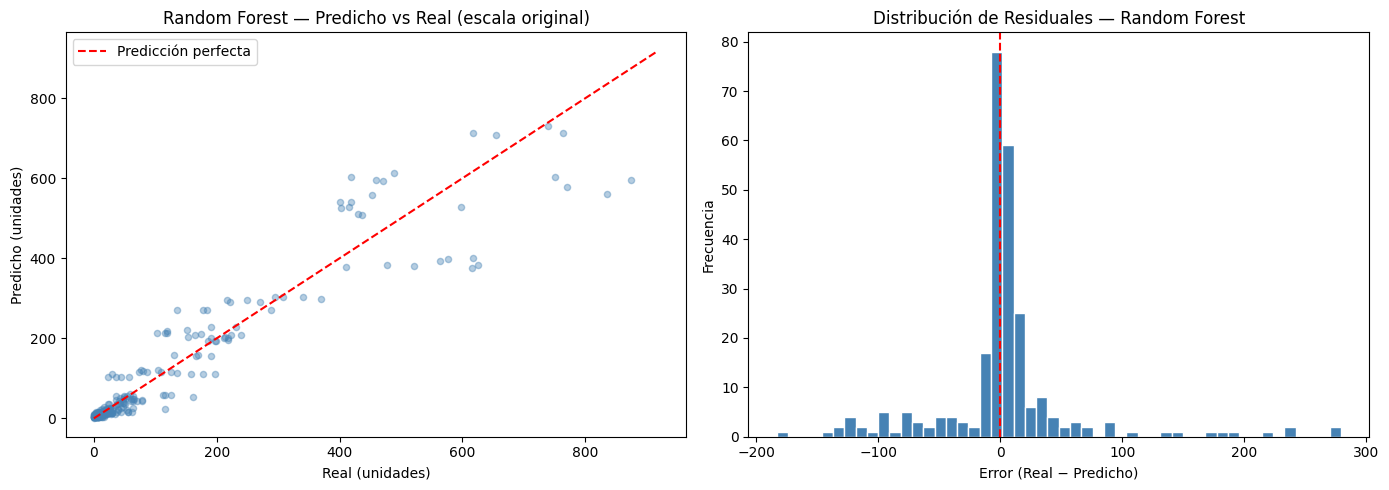

Sesgo medio (bias): 2.6821
Std residuales    : 57.6932


In [ ]:
# ── 1. Scatter plot global: Predicho vs Real (escala original) ──────────
y_rf_orig      = np.expm1(y_rf_test)
y_rf_pred_orig = np.expm1(y_rf_pred).clip(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
ax = axes[0]
ax.scatter(y_rf_orig, y_rf_pred_orig, alpha=0.4, s=20, color='steelblue')
lim = max(y_rf_orig.max(), y_rf_pred_orig.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Predicción perfecta')
ax.set_xlabel('Real (unidades)')
ax.set_ylabel('Predicho (unidades)')
ax.set_title('Random Forest — Predicho vs Real (escala original)')
ax.legend()

# Residuales
residuales = y_rf_orig - y_rf_pred_orig
ax2 = axes[1]
ax2.hist(residuales, bins=50, color='steelblue', edgecolor='white')
ax2.axvline(0, color='red', linestyle='--', lw=1.5)
ax2.set_xlabel('Error (Real − Predicho)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de Residuales — Random Forest')

plt.tight_layout()
plt.show()

print(f'Sesgo medio (bias): {residuales.mean():.4f}')
print(f'Std residuales    : {residuales.std():.4f}')

In [ ]:
def tiempo_a_fecha(t):
    """Convierte tiempo=año*12+mes a string 'YYYY-MM'."""
    anio = t // 12
    mes  = t % 12
    if mes == 0:
        mes = 12
        anio -= 1
    return pd.Timestamp(year=anio, month=mes, day=1)

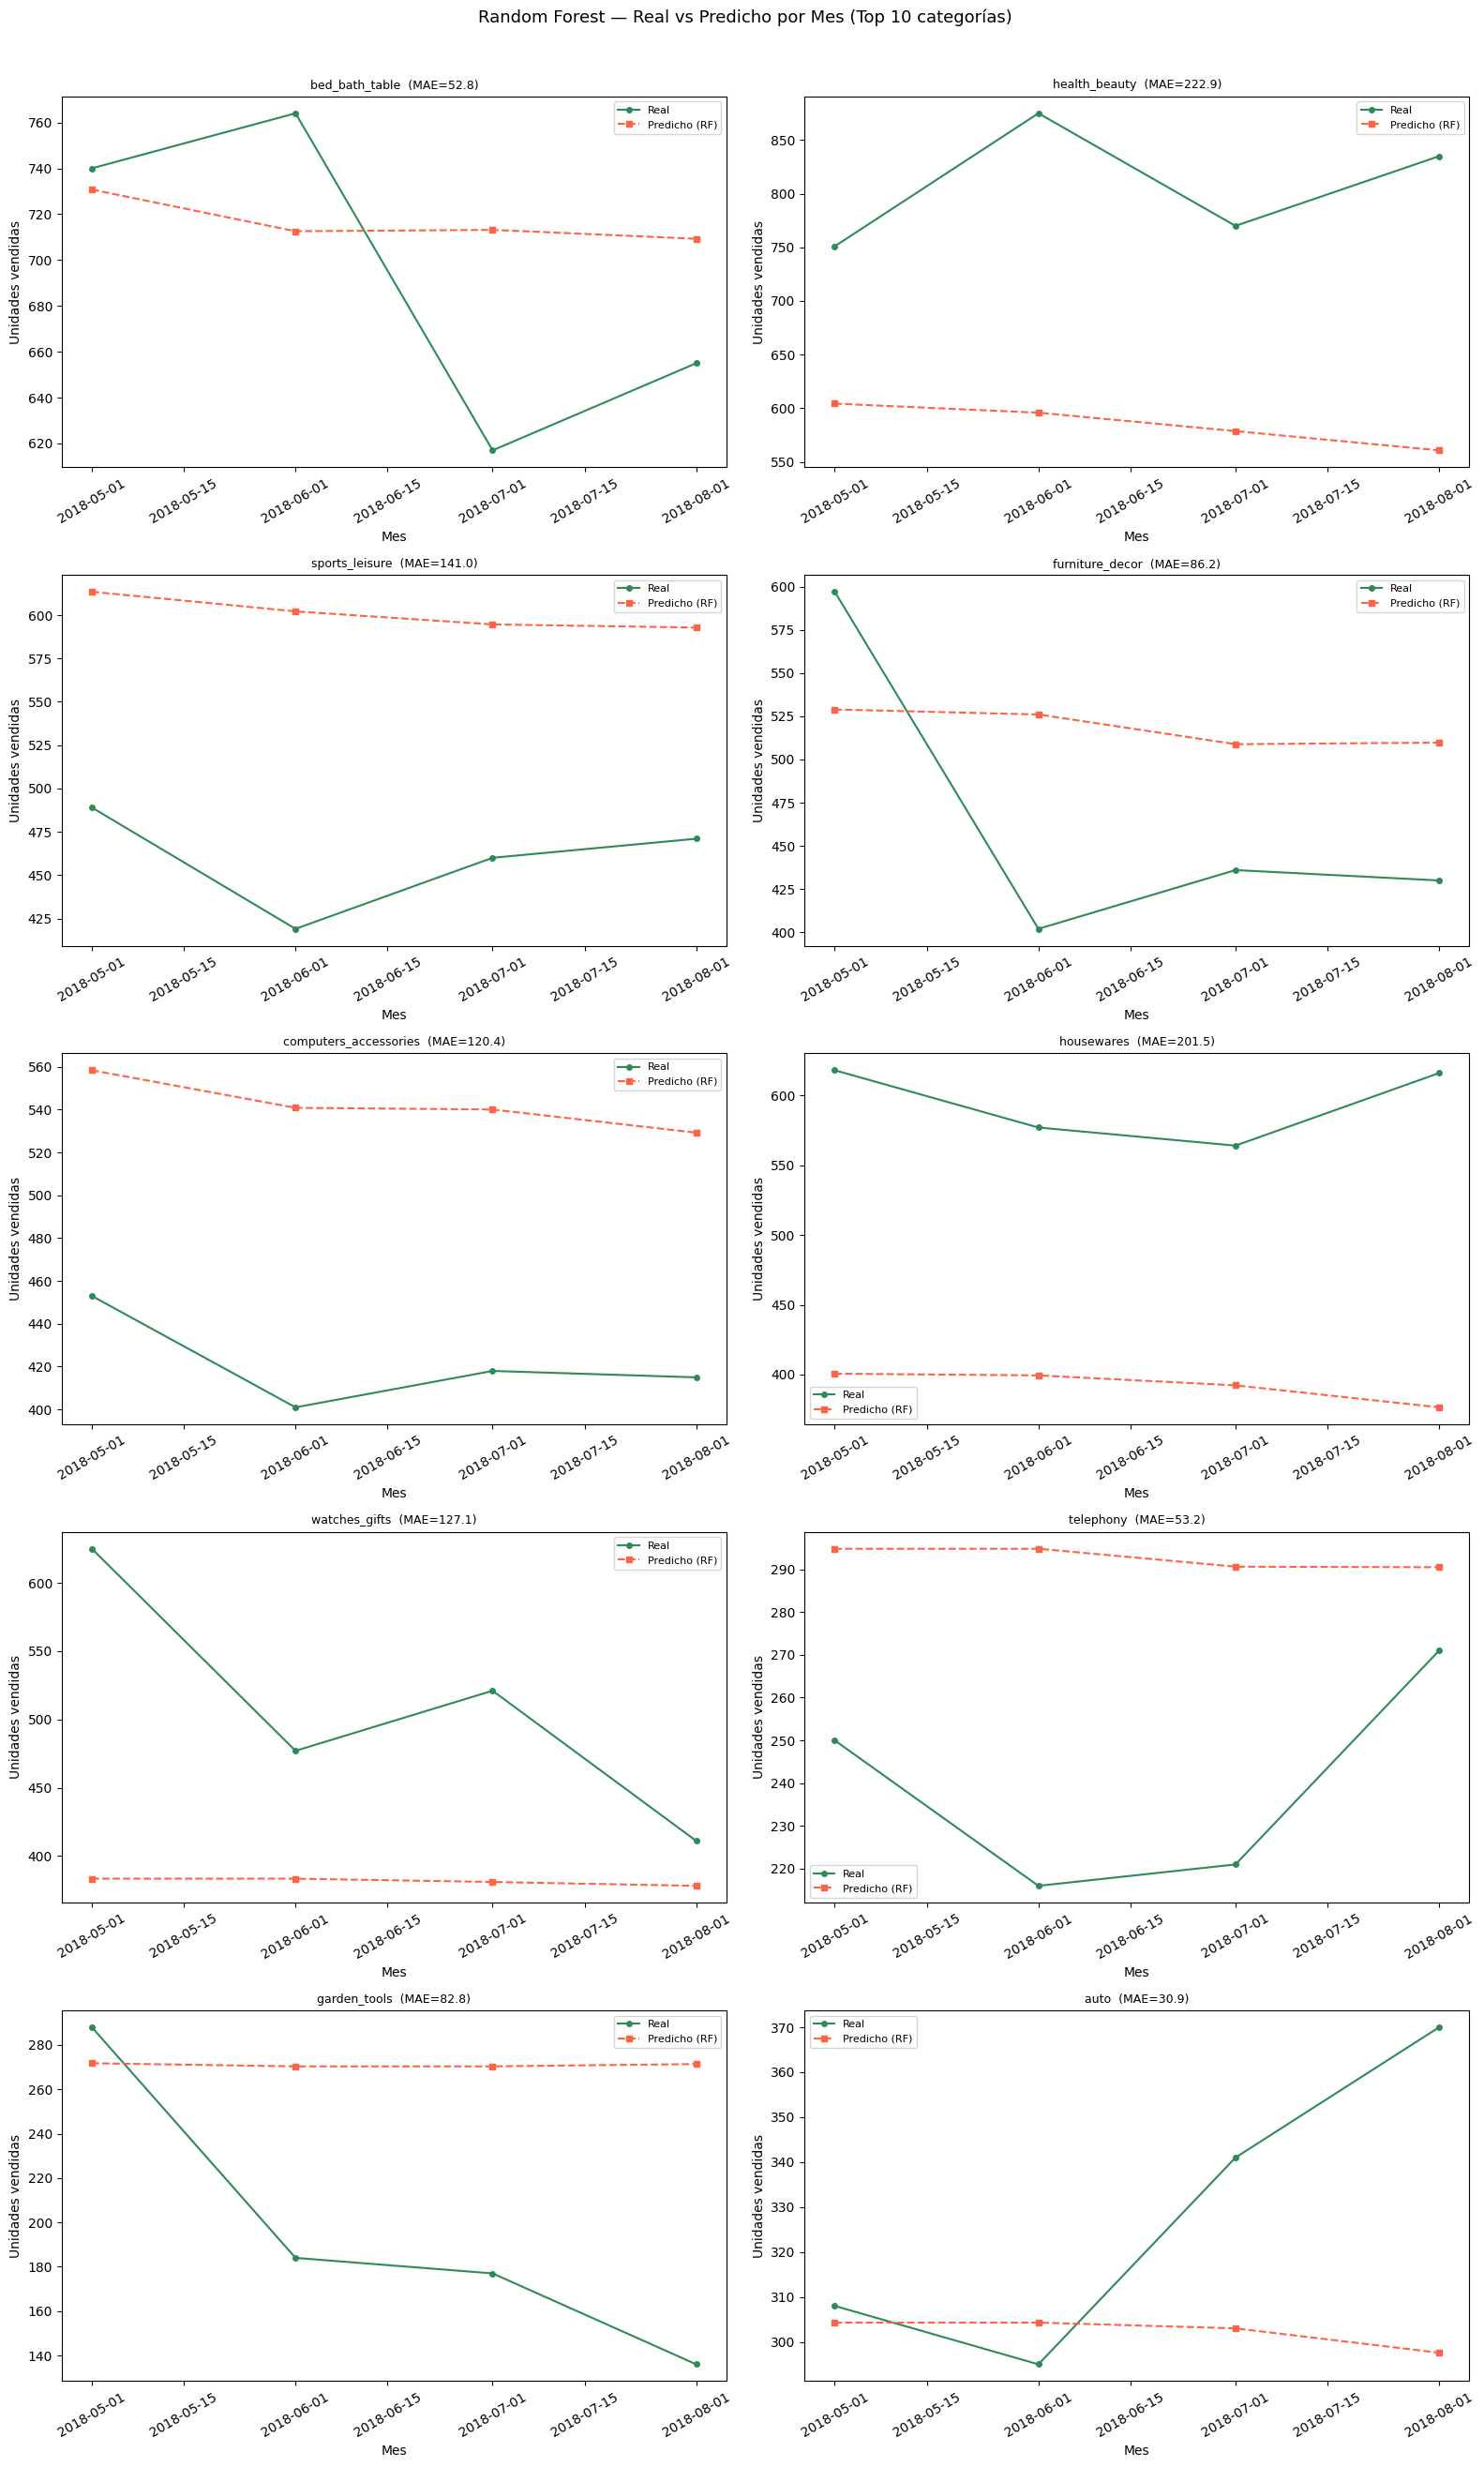

In [219]:
# ── 2. Serie temporal mensual: Real vs Predicho por categoría (Top 10) ──
df_rf_test_eval = df_rf[mask_test].copy()
df_rf_test_eval['y_real']    = np.expm1(y_rf_test)
df_rf_test_eval['y_pred']    = np.expm1(y_rf_pred).clip(0)
df_rf_test_eval['error_abs'] = np.abs(df_rf_test_eval['y_real'] - df_rf_test_eval['y_pred'])
df_rf_test_eval['fecha']     = df_rf_test_eval['tiempo'].apply(tiempo_a_fecha)

top10_rf = (
    df_rf.groupby('tipo_producto')['cantidad']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

fig, axes = plt.subplots(5, 2, figsize=(16, 26))
axes = axes.flatten()

for idx, producto in enumerate(top10_rf):
    sub = df_rf_test_eval[df_rf_test_eval['tipo_producto'] == producto].sort_values('fecha')
    ax  = axes[idx]
    ax.plot(sub['fecha'], sub['y_real'], marker='o', ms=4,
            label='Real', color='seagreen', lw=1.5)
    ax.plot(sub['fecha'], sub['y_pred'], marker='s', ms=4,
            linestyle='--', label='Predicho (RF)', color='tomato', lw=1.5)
    mae_cat = sub['error_abs'].mean()
    ax.set_title(f'{producto}  (MAE={mae_cat:.1f})', fontsize=9)
    ax.set_xlabel('Mes')
    ax.set_ylabel('Unidades vendidas')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.suptitle('Random Forest — Real vs Predicho por Mes (Top 10 categorías)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 5.4 Importancia de Variables

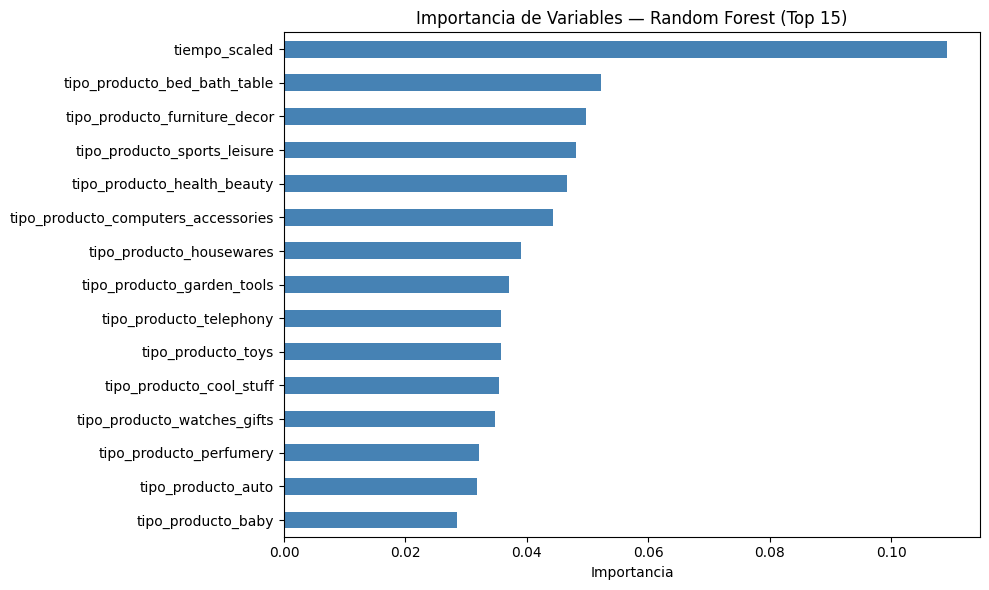

tiempo_scaled y mes_num capturan la dinamica temporal,
las variables de categoria reflejan el impacto diferencial por tipo de producto.


In [ ]:
feature_names = list(X_rf.columns)
importancias = pd.Series(modelo_rf.feature_importances_, index=feature_names)
top_features = importancias.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.title('Importancia de Variables — Random Forest (Top 15)')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('tiempo_scaled y mes_num capturan la dinamica temporal,')
print('las variables de categoria reflejan el impacto diferencial por tipo de producto.')

##5.5 Interpretación


Random Forest permite capturar relaciones no lineales entre el tiempo y la cantidad vendida, lo que le otorga una ventaja frente a la regresión lineal cuando las series presentan patrones más complejos o comportamientos no estrictamente crecientes. Además, al incorporar variables temporales y la categoría del producto, el modelo puede aprender diferencias específicas entre segmentos sin imponer una forma funcional fija.

En comparación con la regresión lineal, Random Forest suele ofrecer mejor desempeño predictivo cuando existen interacciones, cambios abruptos o heterogeneidad entre categorías. Frente a ARIMA, presenta la ventaja de integrar múltiples variables explicativas y no depender exclusivamente de la estructura autorregresiva de una serie univariada.

La interpretación de importancia de variables permite identificar qué factores influyen más en la predicción, reforzando la utilidad del modelo no solo desde la precisión, sino también desde la comprensión del comportamiento de ventas por categoría.

# 6. Análisis No Supervisado: Segmentación con KMeans

**Justificación:** KMeans agrupa entidades en función de similitudes en sus patrones de venta, sin necesidad de etiquetas previas. El objetivo es segmentar las categorías de producto según:

*   Volumen total de ventas
*   Venta media por período
*   Variabilidad (desviación estándar)
*   Tendencia (creciente/decreciente)

Esto permite identificar segmentos como* productos de alta demanda estable, productos en crecimiento y productos de nicho de baja rotación*, aportando valor al TFM para la priorización de recursos de forecasting.

In [221]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy import stats as sp_stats

## 6.1 Feature Engineering para Clustering

In [222]:
def calcular_tendencia(grupo):
    """Pendiente de regresion lineal de cantidad vs tiempo."""
    if len(grupo) < 2:
        return 0.0
    slope, _, _, _, _ = sp_stats.linregress(grupo['tiempo'], grupo['cantidad'])
    return slope

perfil = df_agg.groupby('tipo_producto').agg(
    total_cantidad=('cantidad', 'sum'),
    media_cantidad=('cantidad', 'mean'),
    std_cantidad  =('cantidad', 'std'),
    max_cantidad  =('cantidad', 'max'),
    n_periodos    =('cantidad', 'count')
).fillna(0).reset_index()

tendencias = df_agg.groupby('tipo_producto').apply(calcular_tendencia).reset_index()
tendencias.columns = ['tipo_producto', 'tendencia']
perfil = perfil.merge(tendencias, on='tipo_producto')

print(f'Categorias a segmentar: {len(perfil)}')
perfil.head()

Categorias a segmentar: 72


,tipo_producto,total_cantidad,media_cantidad,std_cantidad,max_cantidad,n_periodos,tendencia
0,agro_industry_and_commerce,206,10.842105,8.889839,27,19,1.048346
1,air_conditioning,289,13.761905,6.934730,29,21,0.573259
2,art,197,10.944444,10.574510,34,18,1.524252
3,arts_and_craftmanship,24,4.000000,4.690416,11,6,0.480392
4,audio,362,18.100000,10.140591,36,20,1.099583


## 6.2 Método del Codo (Elbow Method)

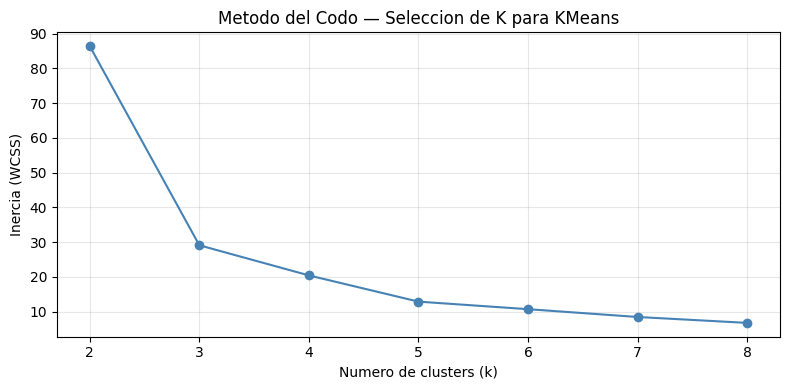

Seleccionamos k=3 segun el punto de inflexion del codo.


In [223]:
features_cluster = ['total_cantidad', 'media_cantidad', 'std_cantidad', 'max_cantidad', 'tendencia']
X_cluster = perfil[features_cluster].values

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

inercias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inercias, marker='o', color='steelblue')
plt.title('Metodo del Codo — Seleccion de K para KMeans')
plt.xlabel('Numero de clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Seleccionamos k=3 segun el punto de inflexion del codo.')

## 6.3 KMeans + Visualización con PCA

Silhouette Score final (k=3): 0.757
  > 0.5 = estructura fuerte | 0.25–0.5 = razonable | < 0.25 = débil

Varianza explicada: PC1=98.0%, PC2=1.4%

Etiquetas asignadas:
 cluster              segmento  n_categorias
       0           Venta media            10
       1 Nicho / baja rotación            55
       2          Ventas Altas             7


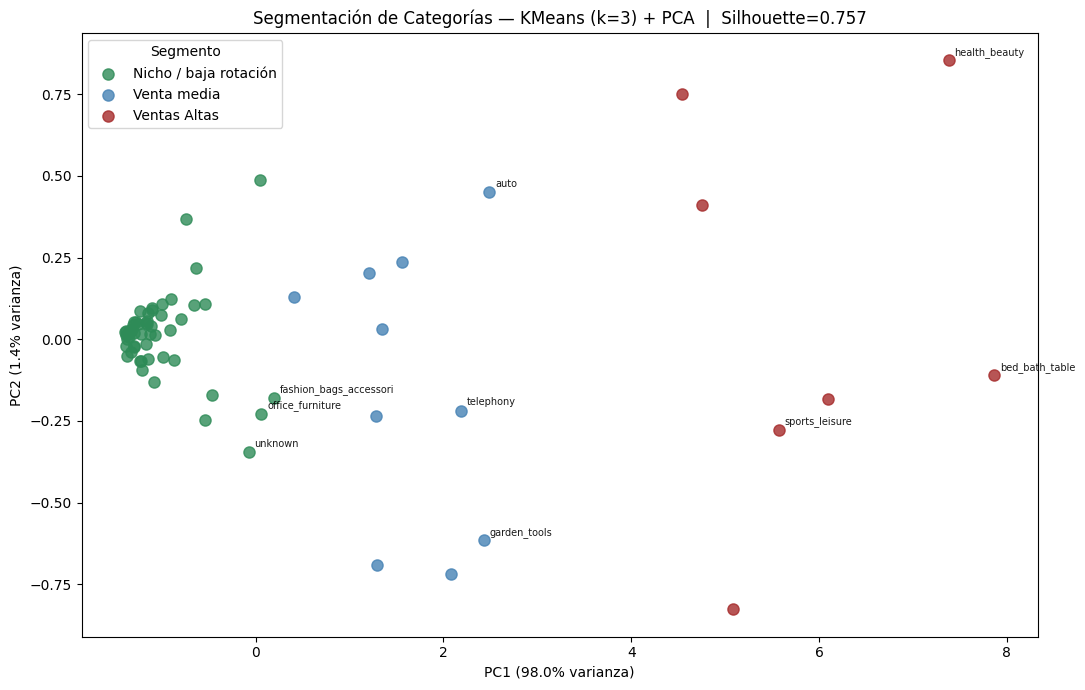

In [224]:

k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
perfil['cluster'] = kmeans.fit_predict(X_cluster_scaled)

score_final = silhouette_score(X_cluster_scaled, perfil['cluster'])
print(f'Silhouette Score final (k={k_optimo}): {score_final:.3f}')
print('  > 0.5 = estructura fuerte | 0.25–0.5 = razonable | < 0.25 = débil')

# PCA para visualización
pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(X_cluster_scaled)
perfil['pca_1'] = coords_pca[:, 0]
perfil['pca_2'] = coords_pca[:, 1]

print(f'\nVarianza explicada: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')

# ── Asignar etiquetas de negocio según el perfil de cada cluster ─────────
resumen_etiq = perfil.groupby('cluster')['total_cantidad'].mean()
orden_clusters = resumen_etiq.sort_values(ascending=False).index.tolist()

etiquetas_negocio = {}
nombres = ['Ventas Altas', 'Venta media', 'Nicho / baja rotación']
for rank, c in enumerate(orden_clusters[:len(nombres)]):
    etiquetas_negocio[c] = nombres[rank]
# Cualquier cluster extra (si k>3) queda con etiqueta genérica
for c in range(k_optimo):
    if c not in etiquetas_negocio:
        etiquetas_negocio[c] = f'Cluster {c}'

perfil['segmento'] = perfil['cluster'].map(etiquetas_negocio)
print('\nEtiquetas asignadas:')
print(perfil.groupby(['cluster','segmento']).size().reset_index(name='n_categorias').to_string(index=False))

# ── Visualización PCA ────────────────────────────────────────────────────
colores_seg = {'Ventas altas': 'tomato', 'Venta media': 'steelblue',
               'Nicho / baja rotación': 'seagreen'}
colores_default = ['purple','orange','brown','pink']

plt.figure(figsize=(11, 7))
for seg in perfil['segmento'].unique():
    sub = perfil[perfil['segmento'] == seg]
    color = colores_seg.get(seg, colores_default.pop(0))
    plt.scatter(sub['pca_1'], sub['pca_2'], c=color, label=seg, s=65, alpha=0.8)
    for _, row in sub.nlargest(3, 'total_cantidad').iterrows():
        plt.annotate(row['tipo_producto'][:22], (row['pca_1'], row['pca_2']),
                     fontsize=7, alpha=0.9,
                     xytext=(4, 4), textcoords='offset points')

plt.title(f'Segmentación de Categorías — KMeans (k={k_optimo}) + PCA  |  Silhouette={score_final:.3f}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
plt.legend(title='Segmento')
plt.tight_layout()
plt.show()


## 6.4 Caracterización de los Segmentos

=== Perfil Promedio por Segmento ===
                       total_cantidad  media_cantidad  std_cantidad  max_cantidad  tendencia  n_categorias
segmento                                                                                                  
Nicho / baja rotación          342.96           17.86         11.71         44.47       1.18            55
Venta media                   3402.70          162.62         92.54        354.40      10.02            10
Ventas Altas                  8186.71          386.92        213.78        792.71      28.18             7

=== Top 5 categorías por segmento ===

Venta media:
  • telephony
  • garden_tools
  • auto
  • toys
  • cool_stuff

Nicho / baja rotación:
  • fashion_bags_accessories
  • office_furniture
  • unknown
  • consoles_games
  • luggage_accessories


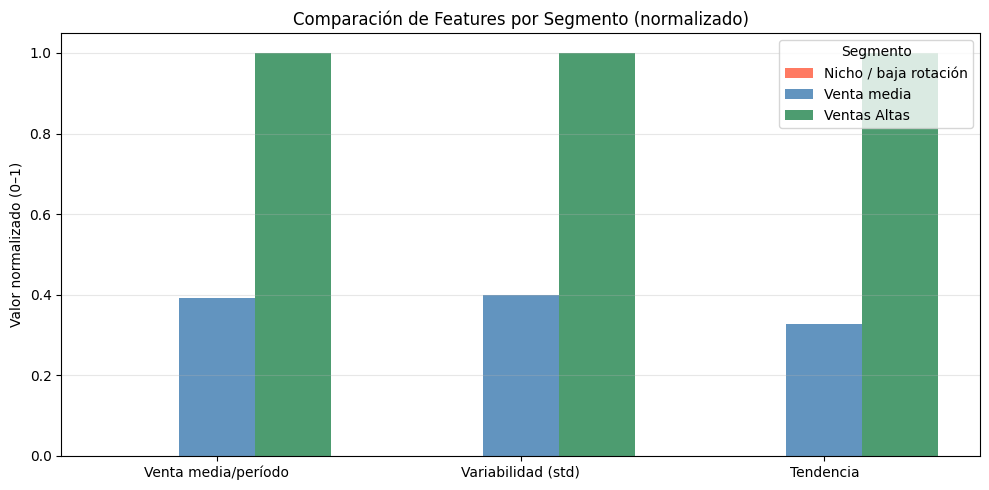

In [225]:
# ── Tabla de perfil promedio por segmento ────────────────────────────────
resumen_clusters = (
    perfil.groupby('segmento')[features_cluster]
    .mean()
    .round(2)
)
resumen_clusters['n_categorias'] = perfil.groupby('segmento')['tipo_producto'].count()

print('=== Perfil Promedio por Segmento ===')
print(resumen_clusters.to_string())

# ── Top 5 categorías por segmento ────────────────────────────────────────
print('\n=== Top 5 categorías por segmento ===')
for seg in ['Ventas altas', 'Venta media', 'Nicho / baja rotación']:
    if seg not in perfil['segmento'].values:
        continue
    cats = (
        perfil[perfil['segmento'] == seg]
        .nlargest(5, 'total_cantidad')['tipo_producto']
        .tolist()
    )
    print(f'\n{seg}:')
    for c in cats:
        print(f'  • {c}')

# ── Gráfico de barras: media de features por segmento ────────────────────
features_plot = ['media_cantidad', 'std_cantidad', 'tendencia']
resumen_norm = resumen_clusters[features_plot].copy()
resumen_norm = (resumen_norm - resumen_norm.min()) / (resumen_norm.max() - resumen_norm.min() + 1e-9)

x = np.arange(len(features_plot))
width = 0.25
segmentos = resumen_norm.index.tolist()
colores_bar = ['tomato', 'steelblue', 'seagreen', 'purple', 'orange']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (seg, color) in enumerate(zip(segmentos, colores_bar)):
    ax.bar(x + i * width, resumen_norm.loc[seg], width, label=seg, color=color, alpha=0.85)

ax.set_xticks(x + width * (len(segmentos) - 1) / 2)
ax.set_xticklabels(['Venta media/período', 'Variabilidad (std)', 'Tendencia'], fontsize=10)
ax.set_ylabel('Valor normalizado (0–1)')
ax.set_title('Comparación de Features por Segmento (normalizado)')
ax.legend(title='Segmento')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6.5 Interpretación de los Segmentos

El análisis de segmentación mediante KMeans permitió identificar tres grupos claramente diferenciados de categorías de producto.

El primer segmento agrupa categorías con altos niveles de ventas y mayor dispersión, lo que indica comportamientos más dinámicos y una mayor complejidad para su modelado.

El segundo segmento corresponde a categorías con niveles intermedios de ventas, presentando patrones más equilibrados.

Por último, el tercer segmento agrupa categorías con baja demanda y menor variabilidad, caracterizándose como productos de nicho con comportamiento más estable.

La proyección mediante PCA muestra que la primera componente principal explica el 98% de la varianza, lo que indica que las diferencias entre categorías están fuertemente determinadas por una dimensión dominante asociada al volumen de ventas.

Estos resultados permiten priorizar el uso de modelos predictivos más complejos en categorías de mayor impacto, optimizando así los recursos analíticos del sistema propuesto.

#7. Uso de ChatGPT como herramienta de apoyo y comunicación

**Justificación:** Se incorpora ChatGPT como herramienta complementaria para la **interpretación y comunicación de resultados** obtenidos a partir de los modelos predictivos. Su función no consiste en generar predicciones ni sustituir los modelos estadísticos o de machine learning, sino en **traducir métricas técnicas y hallazgos cuantitativos en explicaciones comprensibles para usuarios no especializados.**

Esta integración aporta valor al sistema por tres razones principales:

*   Facilita la interpretación de métricas como **MAE, RMSE y R².**
*   Mejora la comunicación de resultados hacia usuarios con perfil no técnico.
*   Refuerza el enfoque práctico del TFM, orientado a pequeñas y medianas empresas.


##7.1 Configuración de la librería y autenticación

En esta versión se implementa una **simulación funcional del comportamiento esperado de ChatGPT**, evitando dependencia de cuota o facturación en el entorno de desarrollo.

In [226]:
# En la versión simulada no es obligatorio usar la API de OpenAI
# Se mantiene una estructura compatible con una futura integración real

import os

##7.2 Función para interpretar resultados de modelos

In [227]:
def interpretar_resultados_modelo(modelo, mae, rmse, r2=None, contexto="predicción de ventas por categoría"):
    texto = f"""
=== Interpretación simulada tipo ChatGPT ===

Modelo: {modelo}
Contexto: {contexto}

1. Interpretación técnica breve:
El modelo presenta un MAE de {mae:.2f} y un RMSE de {rmse:.2f}.
"""

    if r2 is not None:
        texto += f" El valor de R² es {r2:.2f}, lo que permite evaluar la proporción de varianza explicada por el modelo.\n"
    else:
        texto += " En este caso no se dispone de R², ya que el modelo evaluado no utiliza esta métrica como referencia principal.\n"

    texto += f"""
2. Explicación sencilla orientada a negocio:
El modelo {modelo} permite estimar el comportamiento futuro de las ventas con un nivel razonable de precisión, sirviendo como apoyo para planificación, control de stock y toma de decisiones.

3. Limitación principal del modelo:
Aunque ofrece información útil, este modelo puede no capturar completamente cambios bruscos, estacionalidad compleja o relaciones altamente no lineales presentes en los datos.
"""

    return texto

##7.3 Interpretación automática de la Regresión Lineal

In [228]:
texto_lr = interpretar_resultados_modelo(
    modelo="Regresión Lineal",
    mae=mae_orig,
    rmse=rmse_orig,
    r2=r2_lr,
    contexto="forecasting de ventas de productos de e-commerce"
)

print("=== Interpretación tipo ChatGPT (simulada): Regresión Lineal ===")
print(texto_lr)

=== Interpretación tipo ChatGPT (simulada): Regresión Lineal ===

=== Interpretación simulada tipo ChatGPT ===

Modelo: Regresión Lineal
Contexto: forecasting de ventas de productos de e-commerce

1. Interpretación técnica breve:
El modelo presenta un MAE de 89.44 y un RMSE de 173.83.
 El valor de R² es 0.66, lo que permite evaluar la proporción de varianza explicada por el modelo.

2. Explicación sencilla orientada a negocio:
El modelo Regresión Lineal permite estimar el comportamiento futuro de las ventas con un nivel razonable de precisión, sirviendo como apoyo para planificación, control de stock y toma de decisiones.

3. Limitación principal del modelo:
Aunque ofrece información útil, este modelo puede no capturar completamente cambios bruscos, estacionalidad compleja o relaciones altamente no lineales presentes en los datos.



##7.4 Interpretación automática de ARIMA

In [229]:
texto_arima = interpretar_resultados_modelo(
    modelo="ARIMA (1,1,1)",
    mae=resumen_arima["MAE"].mean(),
    rmse=resumen_arima["RMSE"].mean(),
    r2=None,
    contexto="forecasting temporal de ventas por categoría"
)

print("=== Interpretación ChatGPT: ARIMA ===")
print(texto_arima)

=== Interpretación ChatGPT: ARIMA ===

=== Interpretación simulada tipo ChatGPT ===

Modelo: ARIMA (1,1,1)
Contexto: forecasting temporal de ventas por categoría

1. Interpretación técnica breve:
El modelo presenta un MAE de 26.14 y un RMSE de 28.96.
 En este caso no se dispone de R², ya que el modelo evaluado no utiliza esta métrica como referencia principal.

2. Explicación sencilla orientada a negocio:
El modelo ARIMA (1,1,1) permite estimar el comportamiento futuro de las ventas con un nivel razonable de precisión, sirviendo como apoyo para planificación, control de stock y toma de decisiones.

3. Limitación principal del modelo:
Aunque ofrece información útil, este modelo puede no capturar completamente cambios bruscos, estacionalidad compleja o relaciones altamente no lineales presentes en los datos.



##7.5 Interpretación automática de Random Forest

In [230]:
texto_rf = interpretar_resultados_modelo(
    modelo="Random Forest",
    mae=mae_rf,
    rmse=rmse_rf,
    r2=r2_rf,
    contexto="forecasting de ventas de productos de e-commerce"
)

print("=== Interpretación ChatGPT: Random Forest ===")
print(texto_rf)

=== Interpretación ChatGPT: Random Forest ===

=== Interpretación simulada tipo ChatGPT ===

Modelo: Random Forest
Contexto: forecasting de ventas de productos de e-commerce

1. Interpretación técnica breve:
El modelo presenta un MAE de 0.41 y un RMSE de 0.54.
 El valor de R² es 0.89, lo que permite evaluar la proporción de varianza explicada por el modelo.

2. Explicación sencilla orientada a negocio:
El modelo Random Forest permite estimar el comportamiento futuro de las ventas con un nivel razonable de precisión, sirviendo como apoyo para planificación, control de stock y toma de decisiones.

3. Limitación principal del modelo:
Aunque ofrece información útil, este modelo puede no capturar completamente cambios bruscos, estacionalidad compleja o relaciones altamente no lineales presentes en los datos.



##7.6 Almacenamiento de interpretaciones

In [231]:
with open("interpretacion_modelos.txt", "w", encoding="utf-8") as f:
    f.write("=== Regresión Lineal ===\n")
    f.write(texto_lr + "\n\n")
    f.write("=== ARIMA ===\n")
    f.write(texto_arima + "\n\n")
    f.write("=== Random Forest ===\n")
    f.write(texto_rf + "\n")

##7.7 Integración en Streamlit para mostrar la interpretación

In [232]:
# Instalar Streamlit si no está instalado
!pip install streamlit

import streamlit as st
import pandas as pd

# -------------------------------
# Función simulada tipo ChatGPT
# -------------------------------

def interpretar_streamlit(modelo, mae, rmse, r2=None):
    texto = f"""
### Interpretación tipo ChatGPT

**Modelo seleccionado:** {modelo}

#### 1. Interpretación técnica
El modelo presenta un **MAE de {mae:.2f}** y un **RMSE de {rmse:.2f}**.
"""

    if r2 is not None:
        texto += f" Además, el **R² es {r2:.2f}**, lo que permite evaluar la proporción de varianza explicada por el modelo.\n"
    else:
        texto += " En este caso no se dispone de **R²**, ya que este modelo no utiliza dicha métrica como referencia principal.\n"

    texto += f"""
#### 2. Explicación sencilla para negocio
El modelo **{modelo}** permite estimar el comportamiento futuro de las ventas con un nivel razonable de precisión, sirviendo como apoyo para planificación, control de inventario y toma de decisiones.

#### 3. Limitación principal
Aunque ofrece información útil, este modelo puede no capturar completamente cambios bruscos, estacionalidad compleja o relaciones altamente no lineales presentes en los datos.
"""

    return texto


# -------------------------------
# Configuración de página
# -------------------------------

st.set_page_config(page_title="Interpretación de Modelos", layout="wide")

st.title("Interpretación automática de resultados")
st.write(
    "Esta sección muestra una interpretación tipo ChatGPT para facilitar la comprensión "
    "de los resultados de los modelos predictivos."
)

# -------------------------------
# Diccionario de métricas
# Usa aquí las métricas reales ya calculadas
# -------------------------------

metricas_modelos = {
    "Regresión Lineal": {
        "MAE": mae_orig,
        "RMSE": rmse_orig,
        "R2": r2_lr
    },
    "ARIMA": {
        "MAE": resumen_arima["MAE"].mean(),
        "RMSE": resumen_arima["RMSE"].mean(),
        "R2": None
    },
    "Random Forest": {
        "MAE": mae_rf,
        "RMSE": rmse_rf,
        "R2": r2_rf
    }
}

# -------------------------------
# Selector de modelo
# -------------------------------

modelo_seleccionado = st.selectbox(
    "Selecciona el modelo a interpretar",
    list(metricas_modelos.keys())
)

mae_val = metricas_modelos[modelo_seleccionado]["MAE"]
rmse_val = metricas_modelos[modelo_seleccionado]["RMSE"]
r2_val = metricas_modelos[modelo_seleccionado]["R2"]

# -------------------------------
# Mostrar métricas en tarjetas
# -------------------------------

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("MAE", f"{mae_val:.2f}")

with col2:
    st.metric("RMSE", f"{rmse_val:.2f}")

with col3:
    if r2_val is not None:
        st.metric("R²", f"{r2_val:.2f}")
    else:
        st.metric("R²", "N/A")

# -------------------------------
# Botón para generar interpretación
# -------------------------------

if st.button("Generar interpretación"):
    with st.spinner("Generando interpretación..."):
        texto = interpretar_streamlit(
            modelo=modelo_seleccionado,
            mae=mae_val,
            rmse=rmse_val,
            r2=r2_val
        )

    st.markdown("---")
    st.chat_message("assistant").markdown(texto)

# -------------------------------
# Tabla opcional de métricas
# -------------------------------

st.markdown("---")
st.subheader("Resumen comparativo de métricas")

tabla_metricas = pd.DataFrame(metricas_modelos).T.reset_index()
tabla_metricas.columns = ["Modelo", "MAE", "RMSE", "R2"]

st.dataframe(tabla_metricas, use_container_width=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 65.0 MB/s eta 0:00:00


2026-03-29 21:59:10.458 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 21:59:10.459 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 21:59:10.755 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-29 21:59:10.756 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 21:59:10.757 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 21:59:10.760 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 21:59:10.760 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

En la aplicación desarrollada con Streamlit se incorporó un módulo de interpretación automática de resultados, orientado a traducir métricas técnicas en explicaciones comprensibles para el usuario final. Esta funcionalidad actúa como una capa complementaria de comunicación, mejorando la accesibilidad del sistema sin intervenir en el proceso de modelado predictivo.

##7.8 Interpretación metodológica

La incorporación de ChatGPT en el sistema se plantea como una **capa de apoyo interpretativo**, orientada a facilitar la lectura de resultados y la comunicación con el usuario final. En este sentido, no reemplaza el proceso de modelado, sino que complementa la aplicación al convertir métricas y predicciones en explicaciones comprensibles.

En esta implementación, la funcionalidad se presenta mediante una **simulación estructurada del comportamiento esperado**, con el fin de mantener la lógica del sistema sin depender de restricciones externas de cuota o facturación. Esto permite demostrar la viabilidad de la integración dentro del MVP y su valor práctico en contextos empresariales donde la interpretabilidad resulta tan importante como la precisión predictiva

La simulación implementada puede ser reemplazada posteriormente por una integración real con la API de OpenAI, manteniendo la misma estructura funcional del sistema.